In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import tx_rx_system

## Anàlisi de l'Emisor

En aquesta etapa del projecte, ens centrem en el comportament del senyal enviat pel nostre LED driver. L'objectiu és validar que el circuit respon correctament a la freqüència de treball.

### 1. Generació del Senyal de Pols (1 kHz)

Per començar l'anàlisi, simulem la transmissió d'un senyal quadrat. Aquest senyal representa les dades digitals que volem transmetre.
Paràmetres de la Simulació:
- Freqüència: $1\text{ kHz}$ (període de $1\text{ ms}$).
- Amplitud: $3.3\text{ V}$ (nivell lògic estàndard).
- Cicle de treball (Duty Cycle): $50\%$.

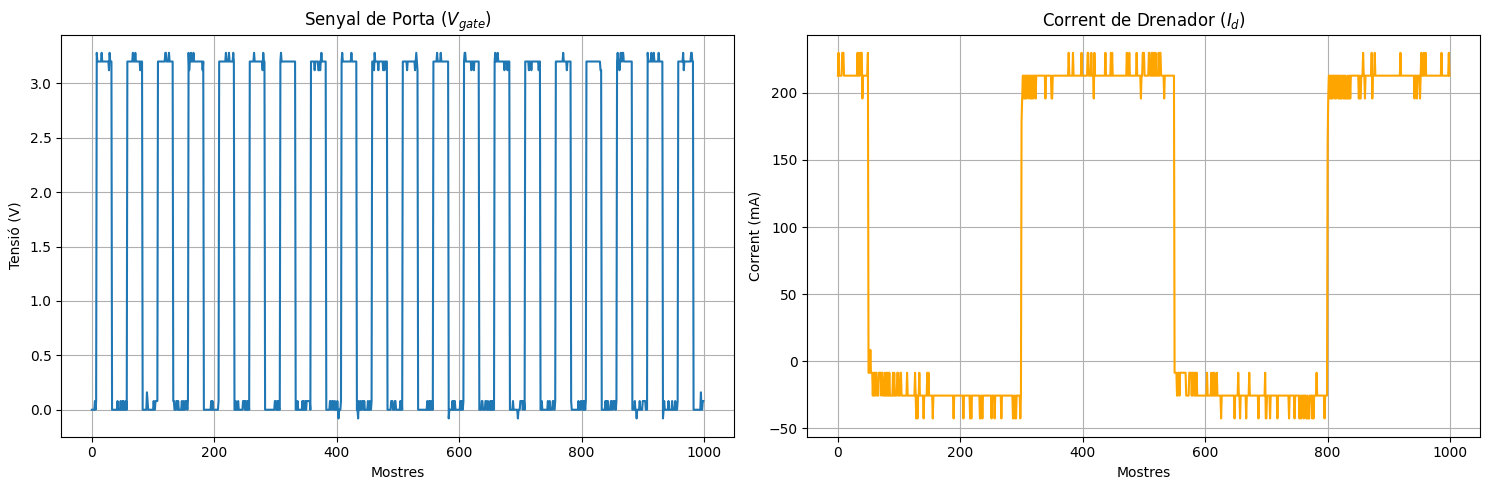

In [2]:
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_V_gate.csv", "fitxers/1kHz_V_gate_neta.csv", channels=1)
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_Id.csv", "fitxers/1kHz_Id_neta.csv", channels=1)

signal_gate = np.loadtxt("fitxers/1kHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1kHz_Id_neta.csv", delimiter=',')

resistencia = 4.7  # Ohms -- L'has mesurada?! 
signal_Id = ((5 - v_mesurada) / resistencia) * 1000  # Els 5V els has mesurat? A tenir en compte: Això és mesura indirecte de la intensitat del corrent elèctric, la precisió depèn de la precisió d' V i R

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(signal_gate[:1000])
ax1.set_title("Senyal de Porta ($V_{gate}$)")
ax1.set_xlabel("Mostres") # Si acaba a la memòria, estaria bé passar de mostres a temps
ax1.set_ylabel("Tensió (V)")
ax1.grid(True)

ax2.plot(signal_Id[:1000], color='orange')
ax2.set_title("Corrent de Drenador ($I_d$)")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True)
plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 2. Generació del Senyal de Pols (1 MHz)

En aquesta secció simulem la transmissió d'un senyal quadrat al sistema.

- Freqüència: 1 MHz.
- Amplitud: 3.3V.
- Objectiu: Demostrar que a aquesta freqüència, el voltatge $V_{gate}$ no té prou temps per carregar-se i assolir pràcticament els 3.3V.


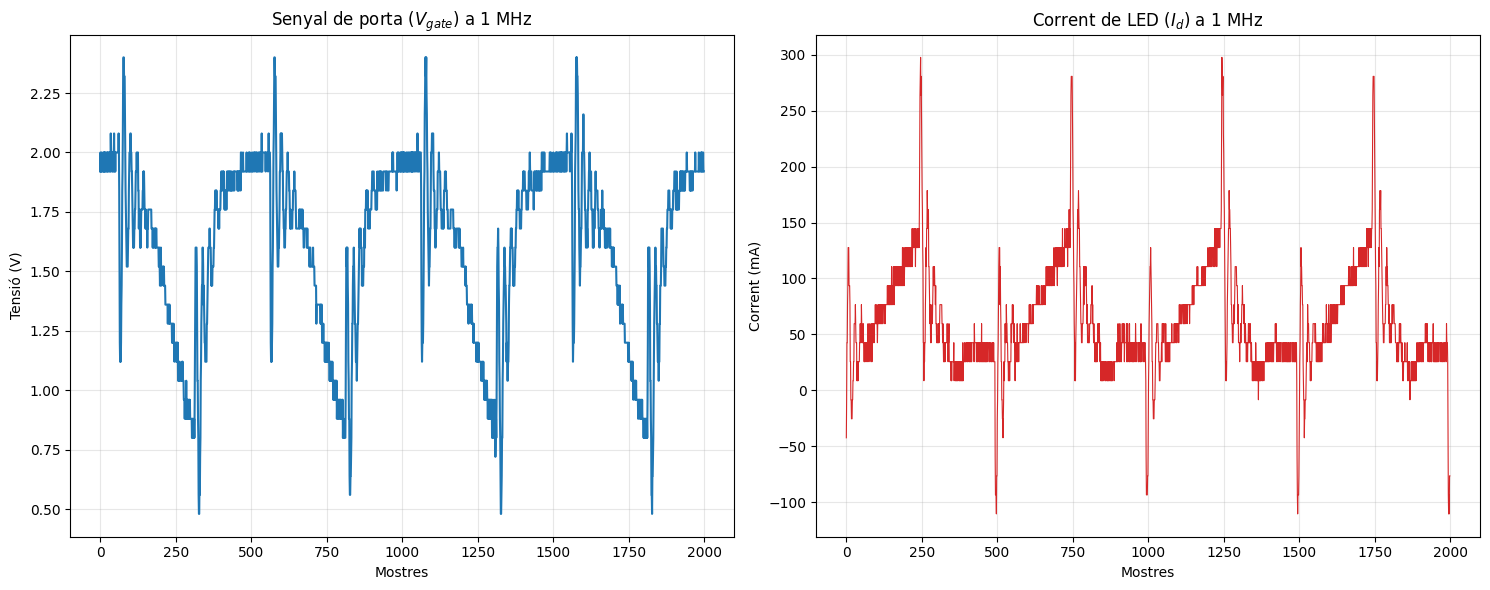

In [3]:
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_V_gate.csv",
    senyal_neta_csv="fitxers/1MHz_V_gate_neta.csv",
    channels=1
)
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_Id.csv",
    senyal_neta_csv="fitxers/1MHz_Id_neta.csv",
    channels=1
)

signal_gate = np.loadtxt("fitxers/1MHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1MHz_Id_neta.csv", delimiter=',')

signal_Id = ((5 - v_mesurada) / resistencia) * 1000
# A tenir en compte: aquí assumeixes que els "5V" no depenen de la freqüència i no és veritat
# e.g., les inducatàncies parasites (L_p) del circuit (+ la que afegeix l'oscil.) + el on-off del driver (di/dt) creen pics de corrent segons freq
# Voltage que cau a R: V(t) = I(t) * R + L_p * di(t)/dt
# La menera més precisa seria mesurar els "5V" amb l'altre canal de l'oscil.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(signal_gate[:2000], color='tab:blue')
ax1.set_title("Senyal de porta ($V_{gate}$) a 1 MHz")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True, alpha=0.3)
ax2.plot(signal_Id[:2000], color='tab:red', linewidth=0.8)
ax2.set_title("Corrent de LED ($I_d$) a 1 MHz")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretació del resultat

## EXPERIMENT 1: Resposta en freq. i ample de banda EMISOR

En aquest apartat es realitza un sweep de freqüència, és a dir, una variació progressiva de la freqüència del senyal d’entrada des de 1 kHz fins a 7.5 MHz, mantenint la resta de paràmetres constants (amplitud i forma del senyal).

#### Objectiu:

L’objectiu principal és analitzar el comportament dinàmic del sistema davant diferents velocitats de commutació, i determinar fins a quina freqüència el sistema és capaç de respondre correctament.

Processing A (Target: 50.000 kHz)...
Guardat: fitxers/BW_TX_v1/a_neta_rx.csv i fitxers/BW_TX_v1/a_neta_tx.csv
  Amplitude: 122.5866 mA  |  Found at: 50.000 kHz
Processing B (Target: 100.000 kHz)...
Guardat: fitxers/BW_TX_v1/b_neta_rx.csv i fitxers/BW_TX_v1/b_neta_tx.csv
  Amplitude: 126.6069 mA  |  Found at: 100.000 kHz
Processing C (Target: 200.000 kHz)...
Guardat: fitxers/BW_TX_v1/c_neta_rx.csv i fitxers/BW_TX_v1/c_neta_tx.csv
  Amplitude: 124.4075 mA  |  Found at: 200.000 kHz
Processing D (Target: 300.000 kHz)...
Guardat: fitxers/BW_TX_v1/d_neta_rx.csv i fitxers/BW_TX_v1/d_neta_tx.csv
  Amplitude: 1.8633 mA  |  Found at: 281.250 kHz
Processing E (Target: 400.000 kHz)...
Guardat: fitxers/BW_TX_v1/e_neta_rx.csv i fitxers/BW_TX_v1/e_neta_tx.csv
  Amplitude: 89.5324 mA  |  Found at: 406.250 kHz
Processing F (Target: 450.000 kHz)...
Guardat: fitxers/BW_TX_v1/f_neta_rx.csv i fitxers/BW_TX_v1/f_neta_tx.csv
  Amplitude: 71.1295 mA  |  Found at: 437.500 kHz
Processing G (Target: 500.000 kHz)

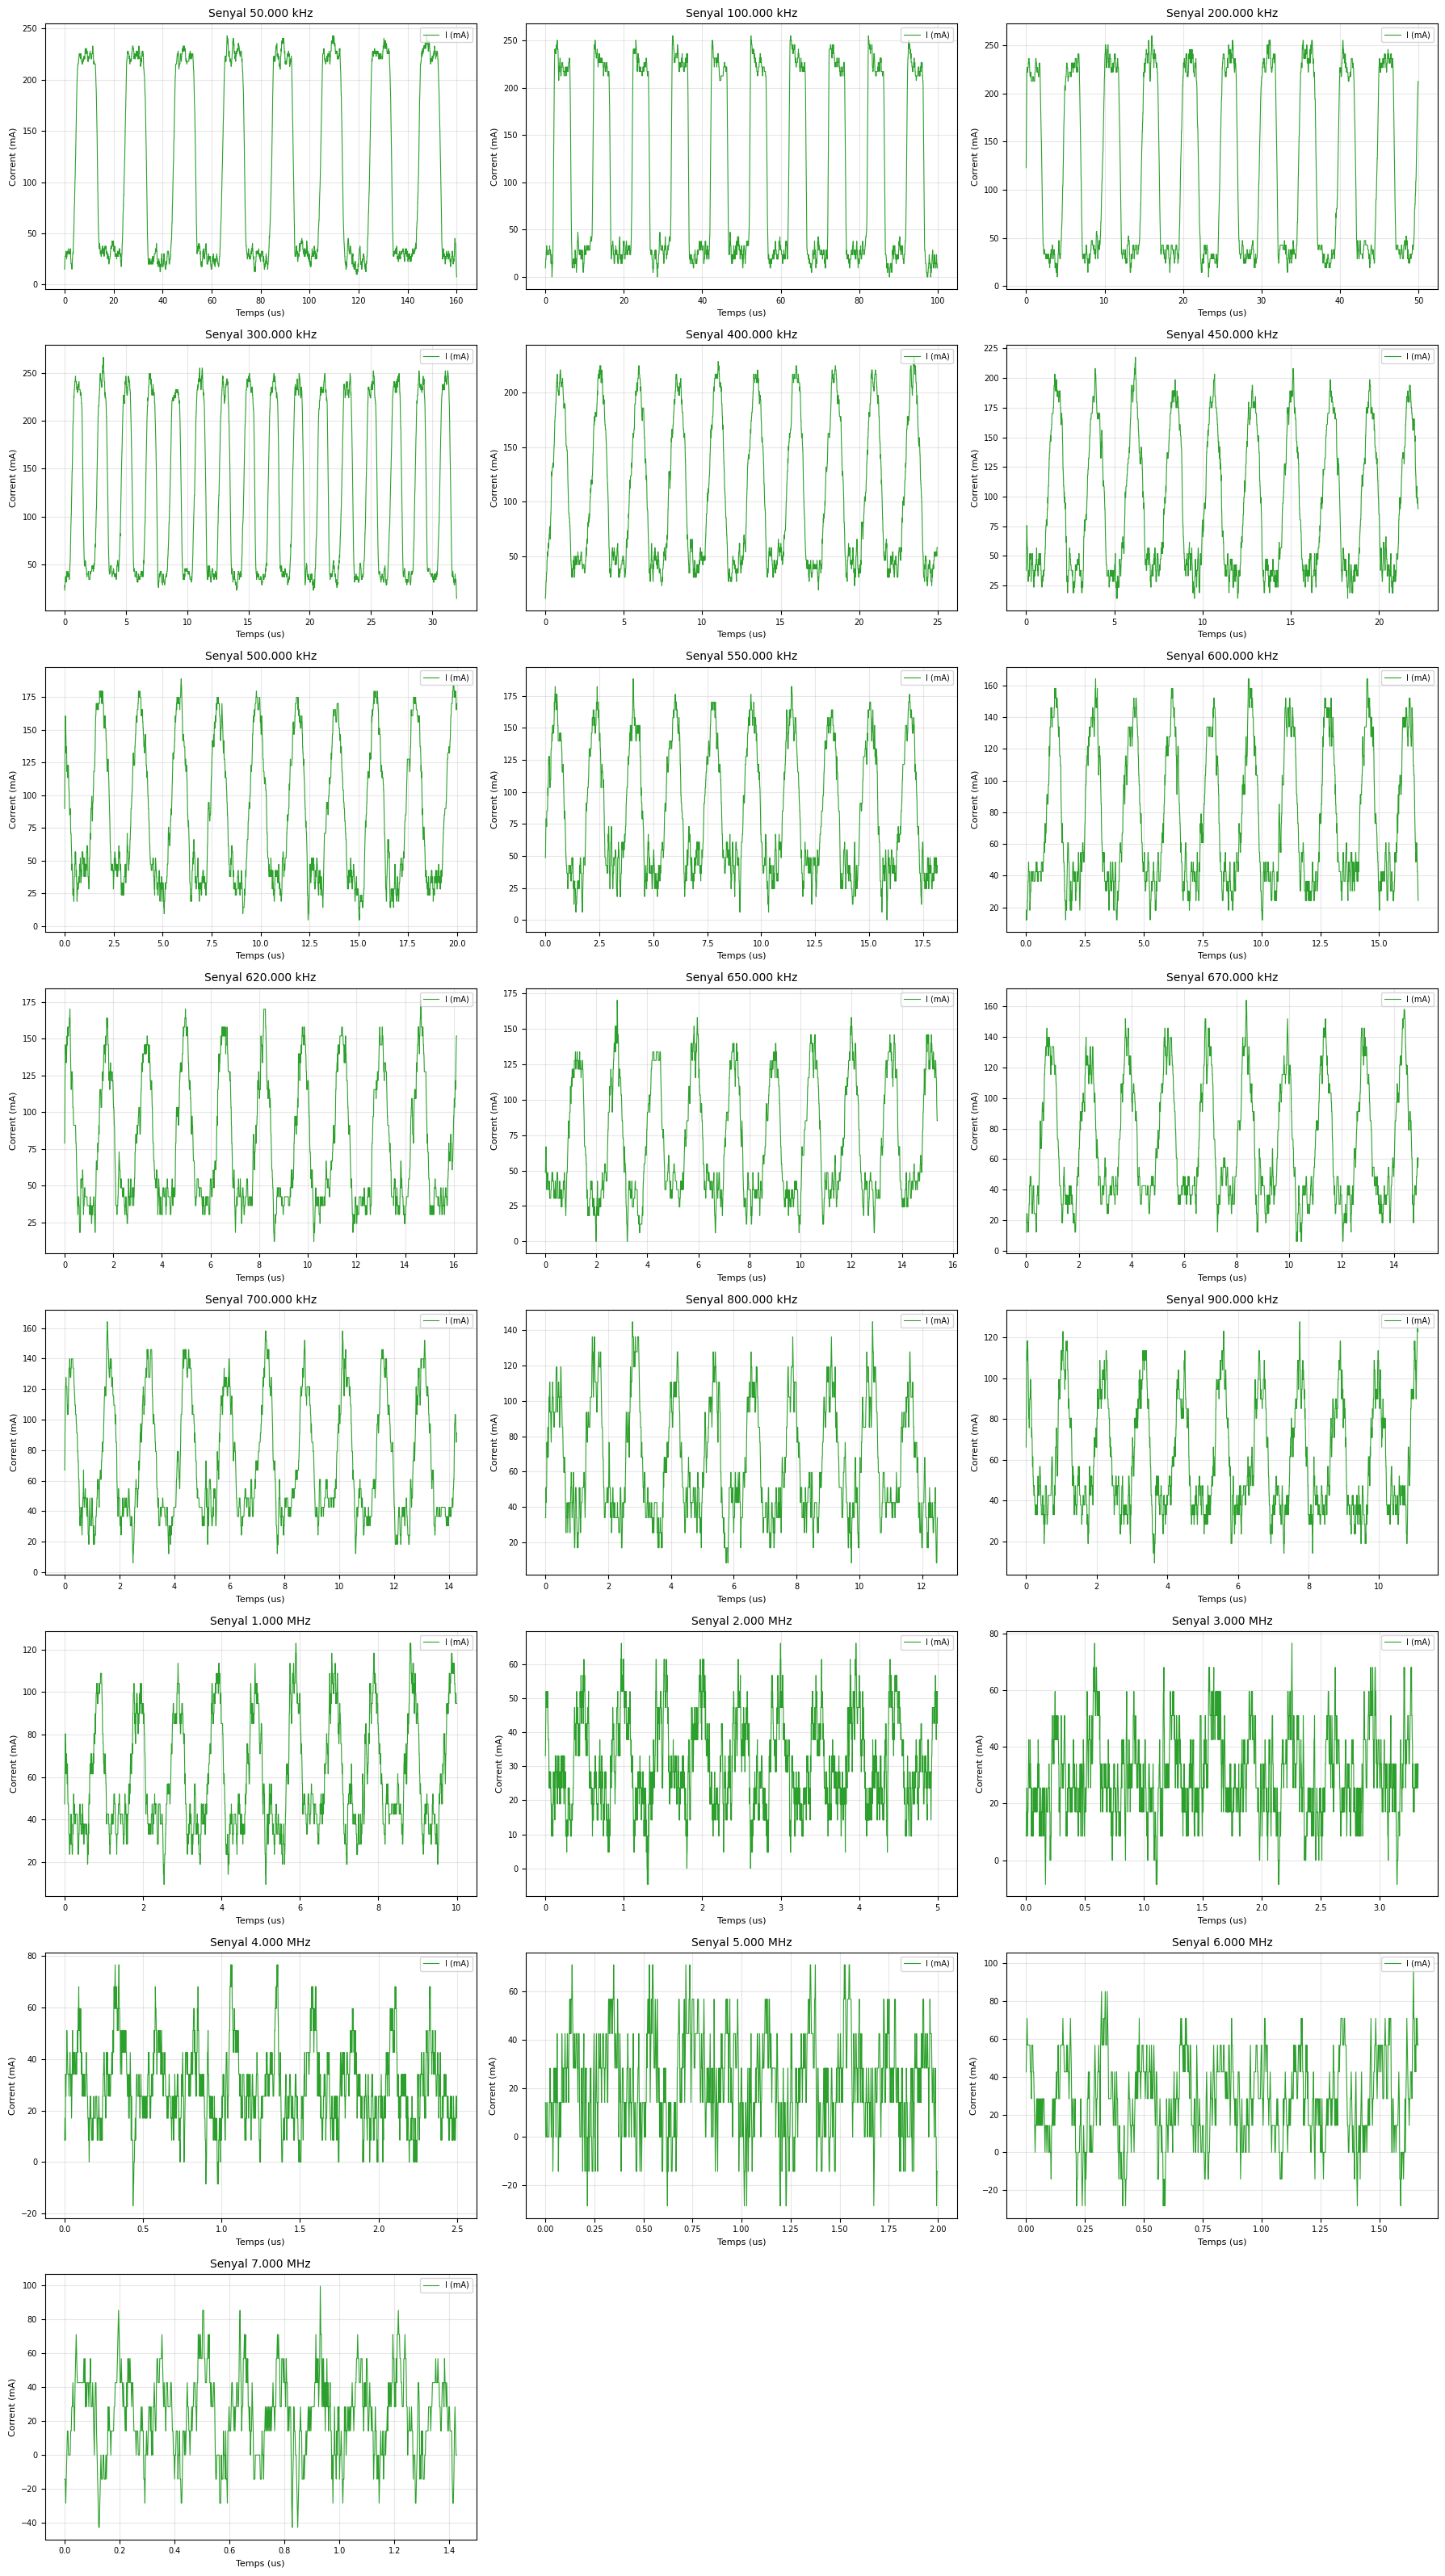

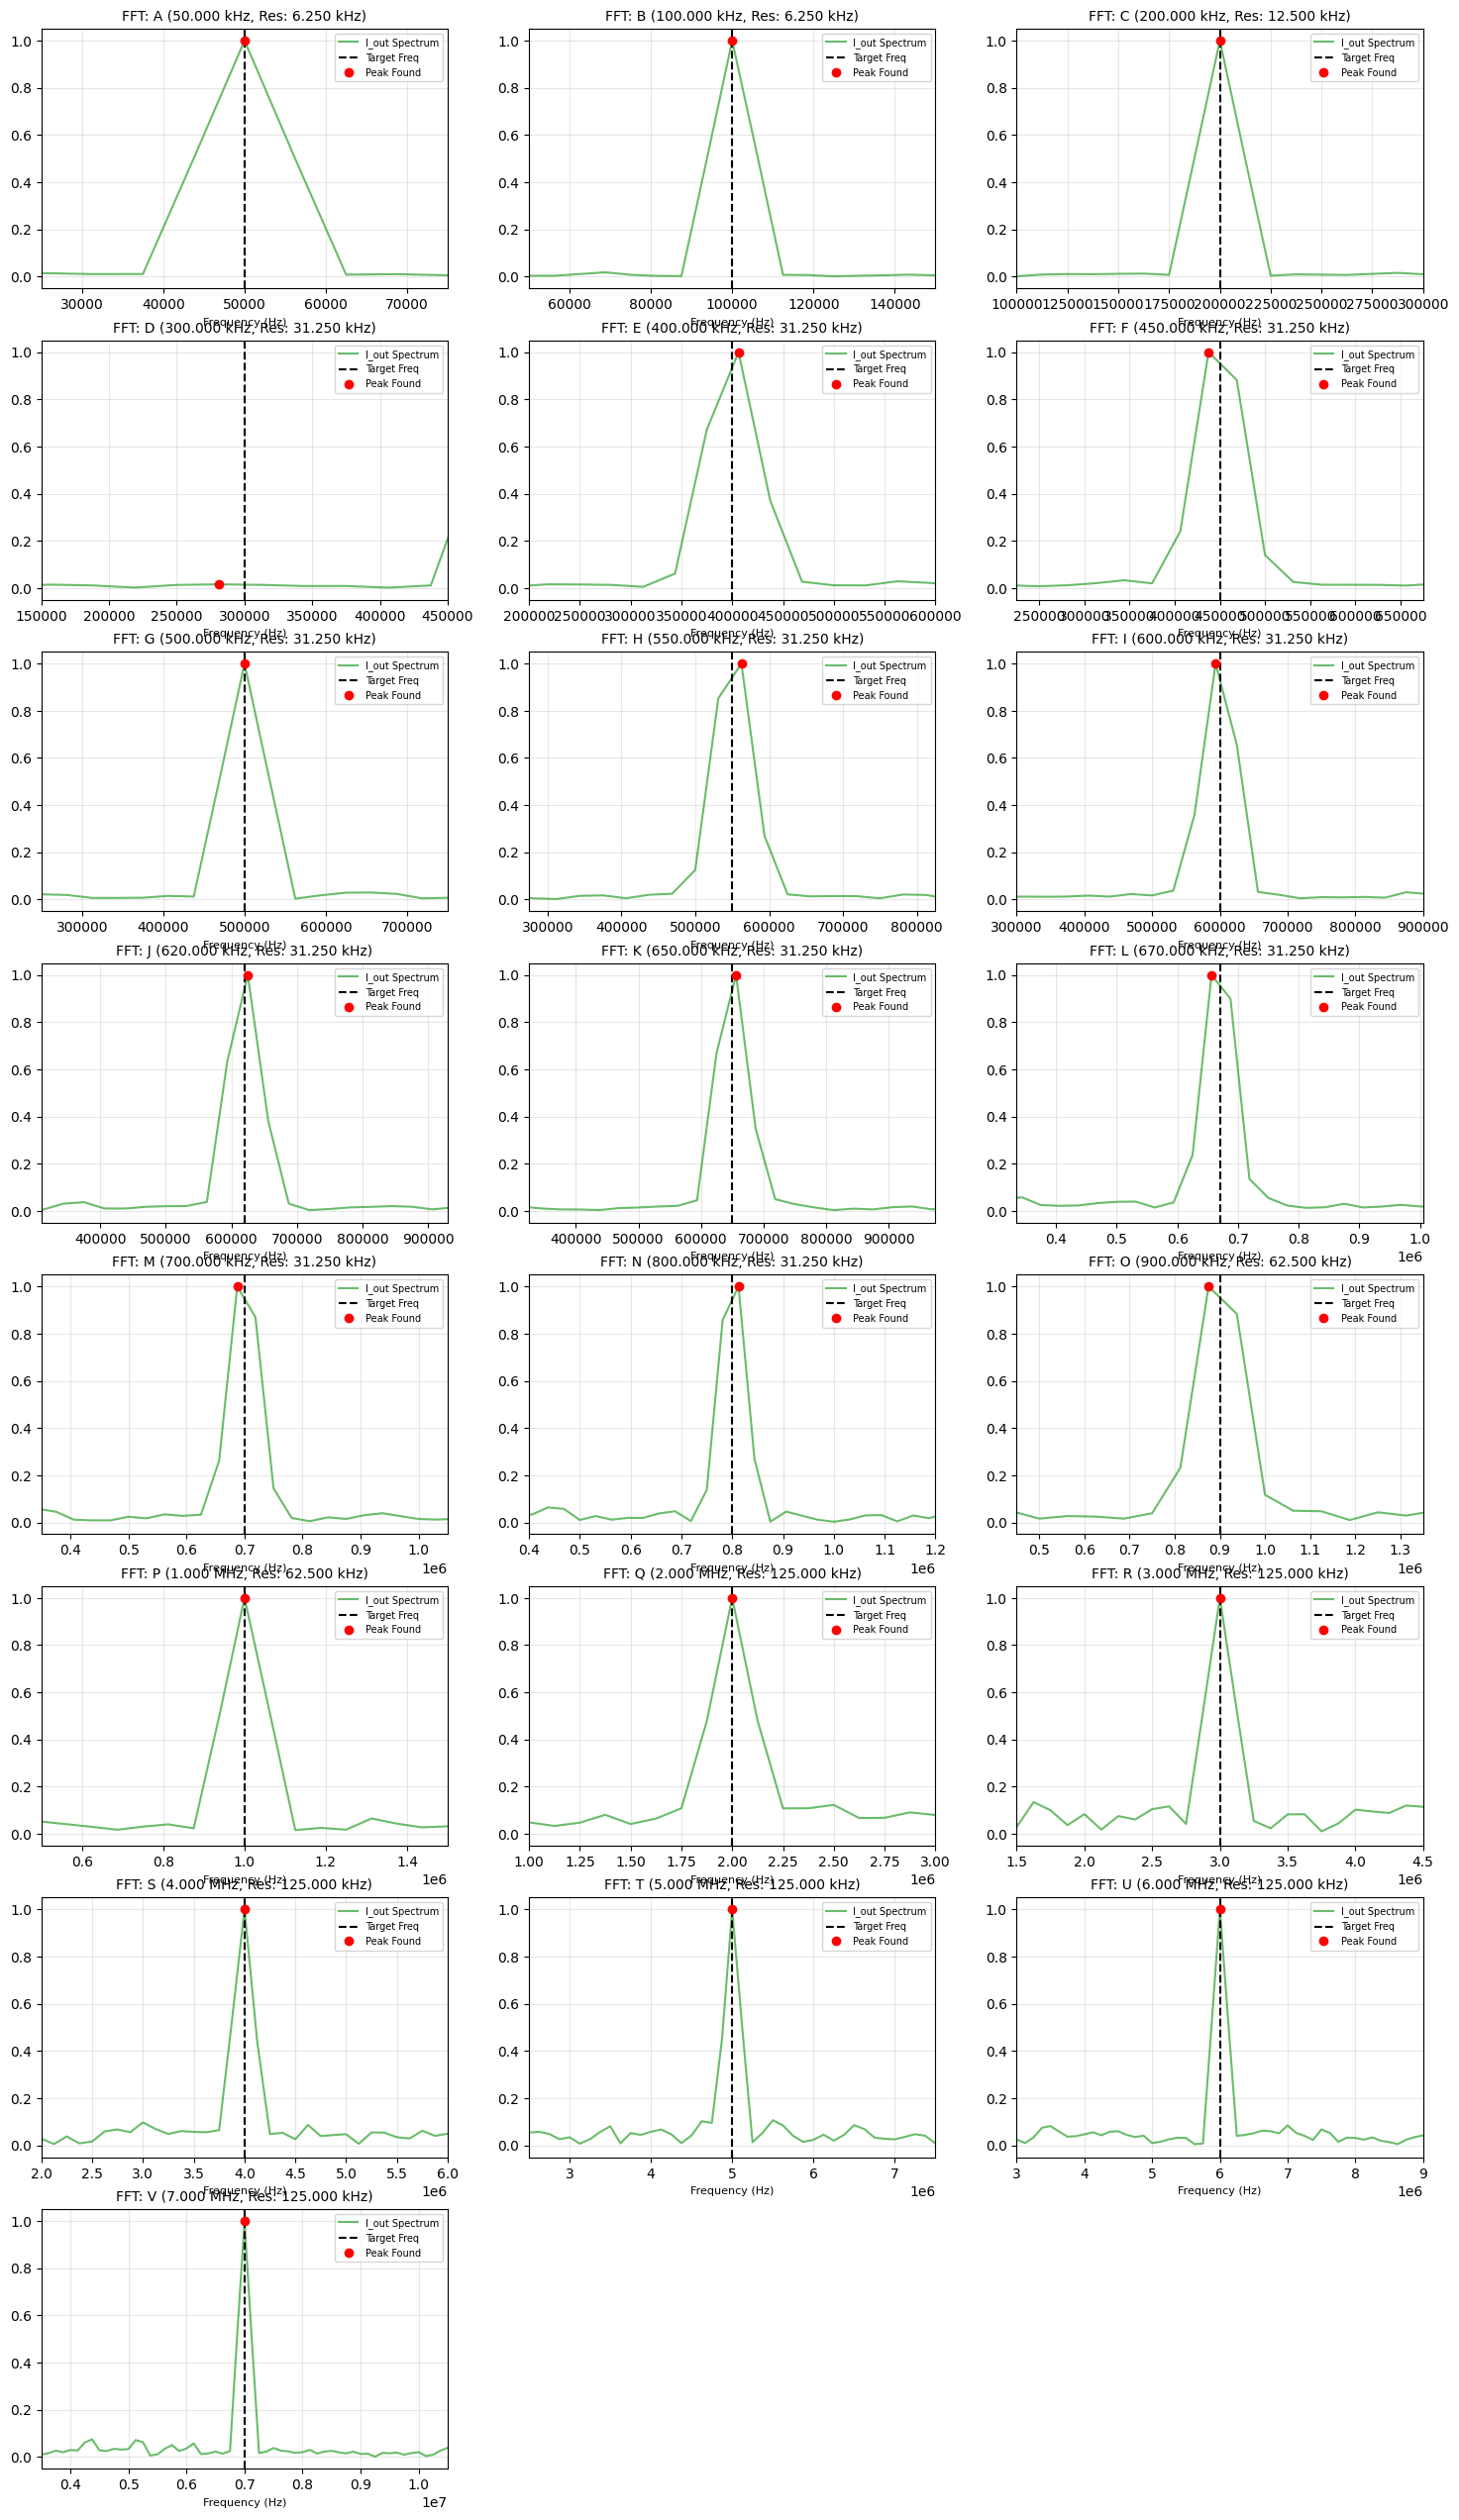

Saved: fitxers/BW_TX_v1/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v1
  Peak Freq:               100.000 kHz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 206.430 kHz
  Low-pass Bandwidth:       206.430 kHz



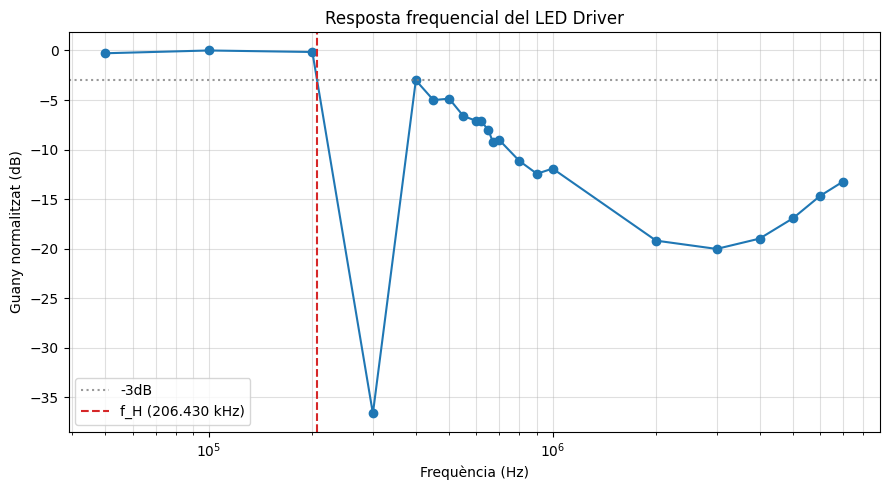

Saved: fitxers/BW_TX_v1/system_frequency_response.png


In [4]:
tx_rx_system.experiment1_BODE(
    freqs=[
        50000, 100000, 200000, 300000, 400000, 450000, 500000, 550000,
        600000, 620000, 650000, 670000, 700000, 800000, 900000, 1000000,
        2000000, 3000000, 4000000, 5000000, 6000000, 7000000,
    ],
    sampling_rates=[
        25e6, 25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 250e6, 250e6,
        500e6, 500e6, 500e6, 500e6, 500e6, 500e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v"],
    folder="BW_TX_v1",
    resistencia=4.7,
)

TODO:  Argumentar: 

Hi havia un problema de sampling point-> Exporràven només 4k i fa que no coincideixin bins. Tornem a utilitzar però ignornat senyal a 300kHx ja que no es pot detectar bé le pic i fa que grafica no funcioni

Processing A (Target: 50.000 kHz)...
Guardat: fitxers/BW_TX_v1/a_neta_rx.csv i fitxers/BW_TX_v1/a_neta_tx.csv
  Amplitude: 122.5866 mA  |  Found at: 50.000 kHz
Processing B (Target: 100.000 kHz)...
Guardat: fitxers/BW_TX_v1/b_neta_rx.csv i fitxers/BW_TX_v1/b_neta_tx.csv
  Amplitude: 126.6069 mA  |  Found at: 100.000 kHz
Processing C (Target: 200.000 kHz)...
Guardat: fitxers/BW_TX_v1/c_neta_rx.csv i fitxers/BW_TX_v1/c_neta_tx.csv
  Amplitude: 124.4075 mA  |  Found at: 200.000 kHz
Processing E (Target: 400.000 kHz)...
Guardat: fitxers/BW_TX_v1/e_neta_rx.csv i fitxers/BW_TX_v1/e_neta_tx.csv
  Amplitude: 89.5324 mA  |  Found at: 406.250 kHz
Processing F (Target: 450.000 kHz)...
Guardat: fitxers/BW_TX_v1/f_neta_rx.csv i fitxers/BW_TX_v1/f_neta_tx.csv
  Amplitude: 71.1295 mA  |  Found at: 437.500 kHz
Processing G (Target: 500.000 kHz)...
Guardat: fitxers/BW_TX_v1/g_neta_rx.csv i fitxers/BW_TX_v1/g_neta_tx.csv
  Amplitude: 72.3420 mA  |  Found at: 500.000 kHz
Processing H (Target: 550.000 kHz

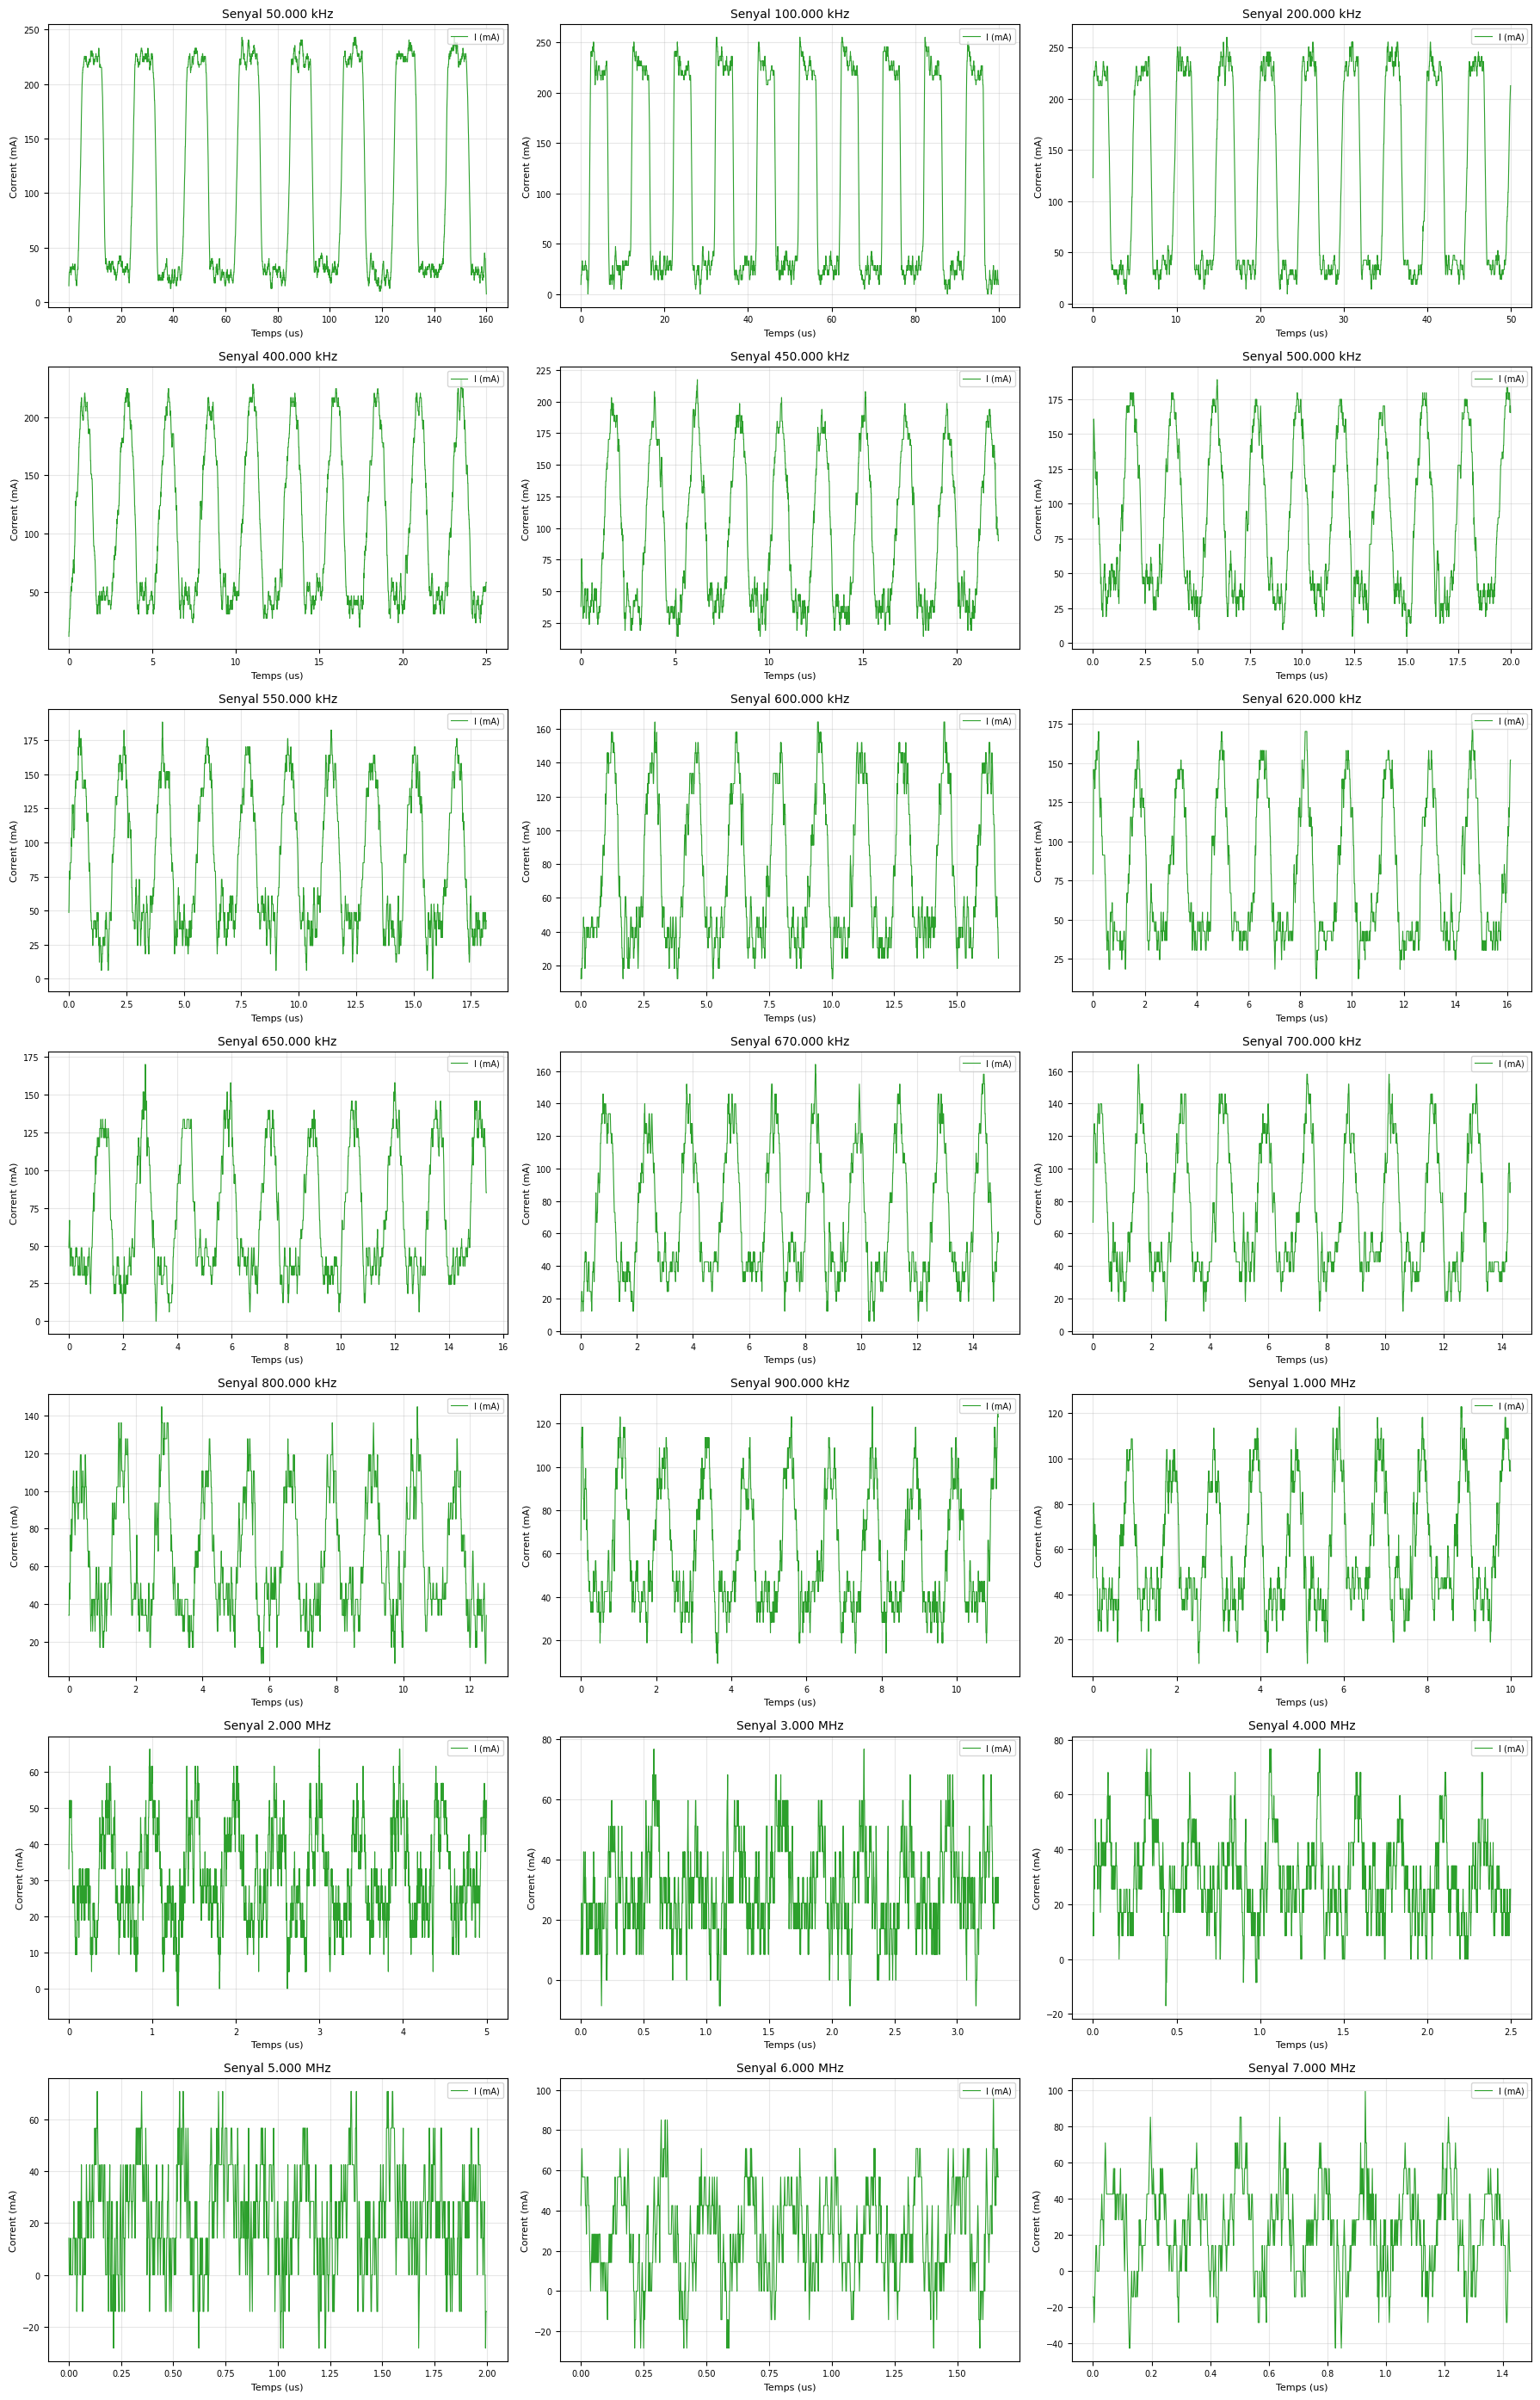

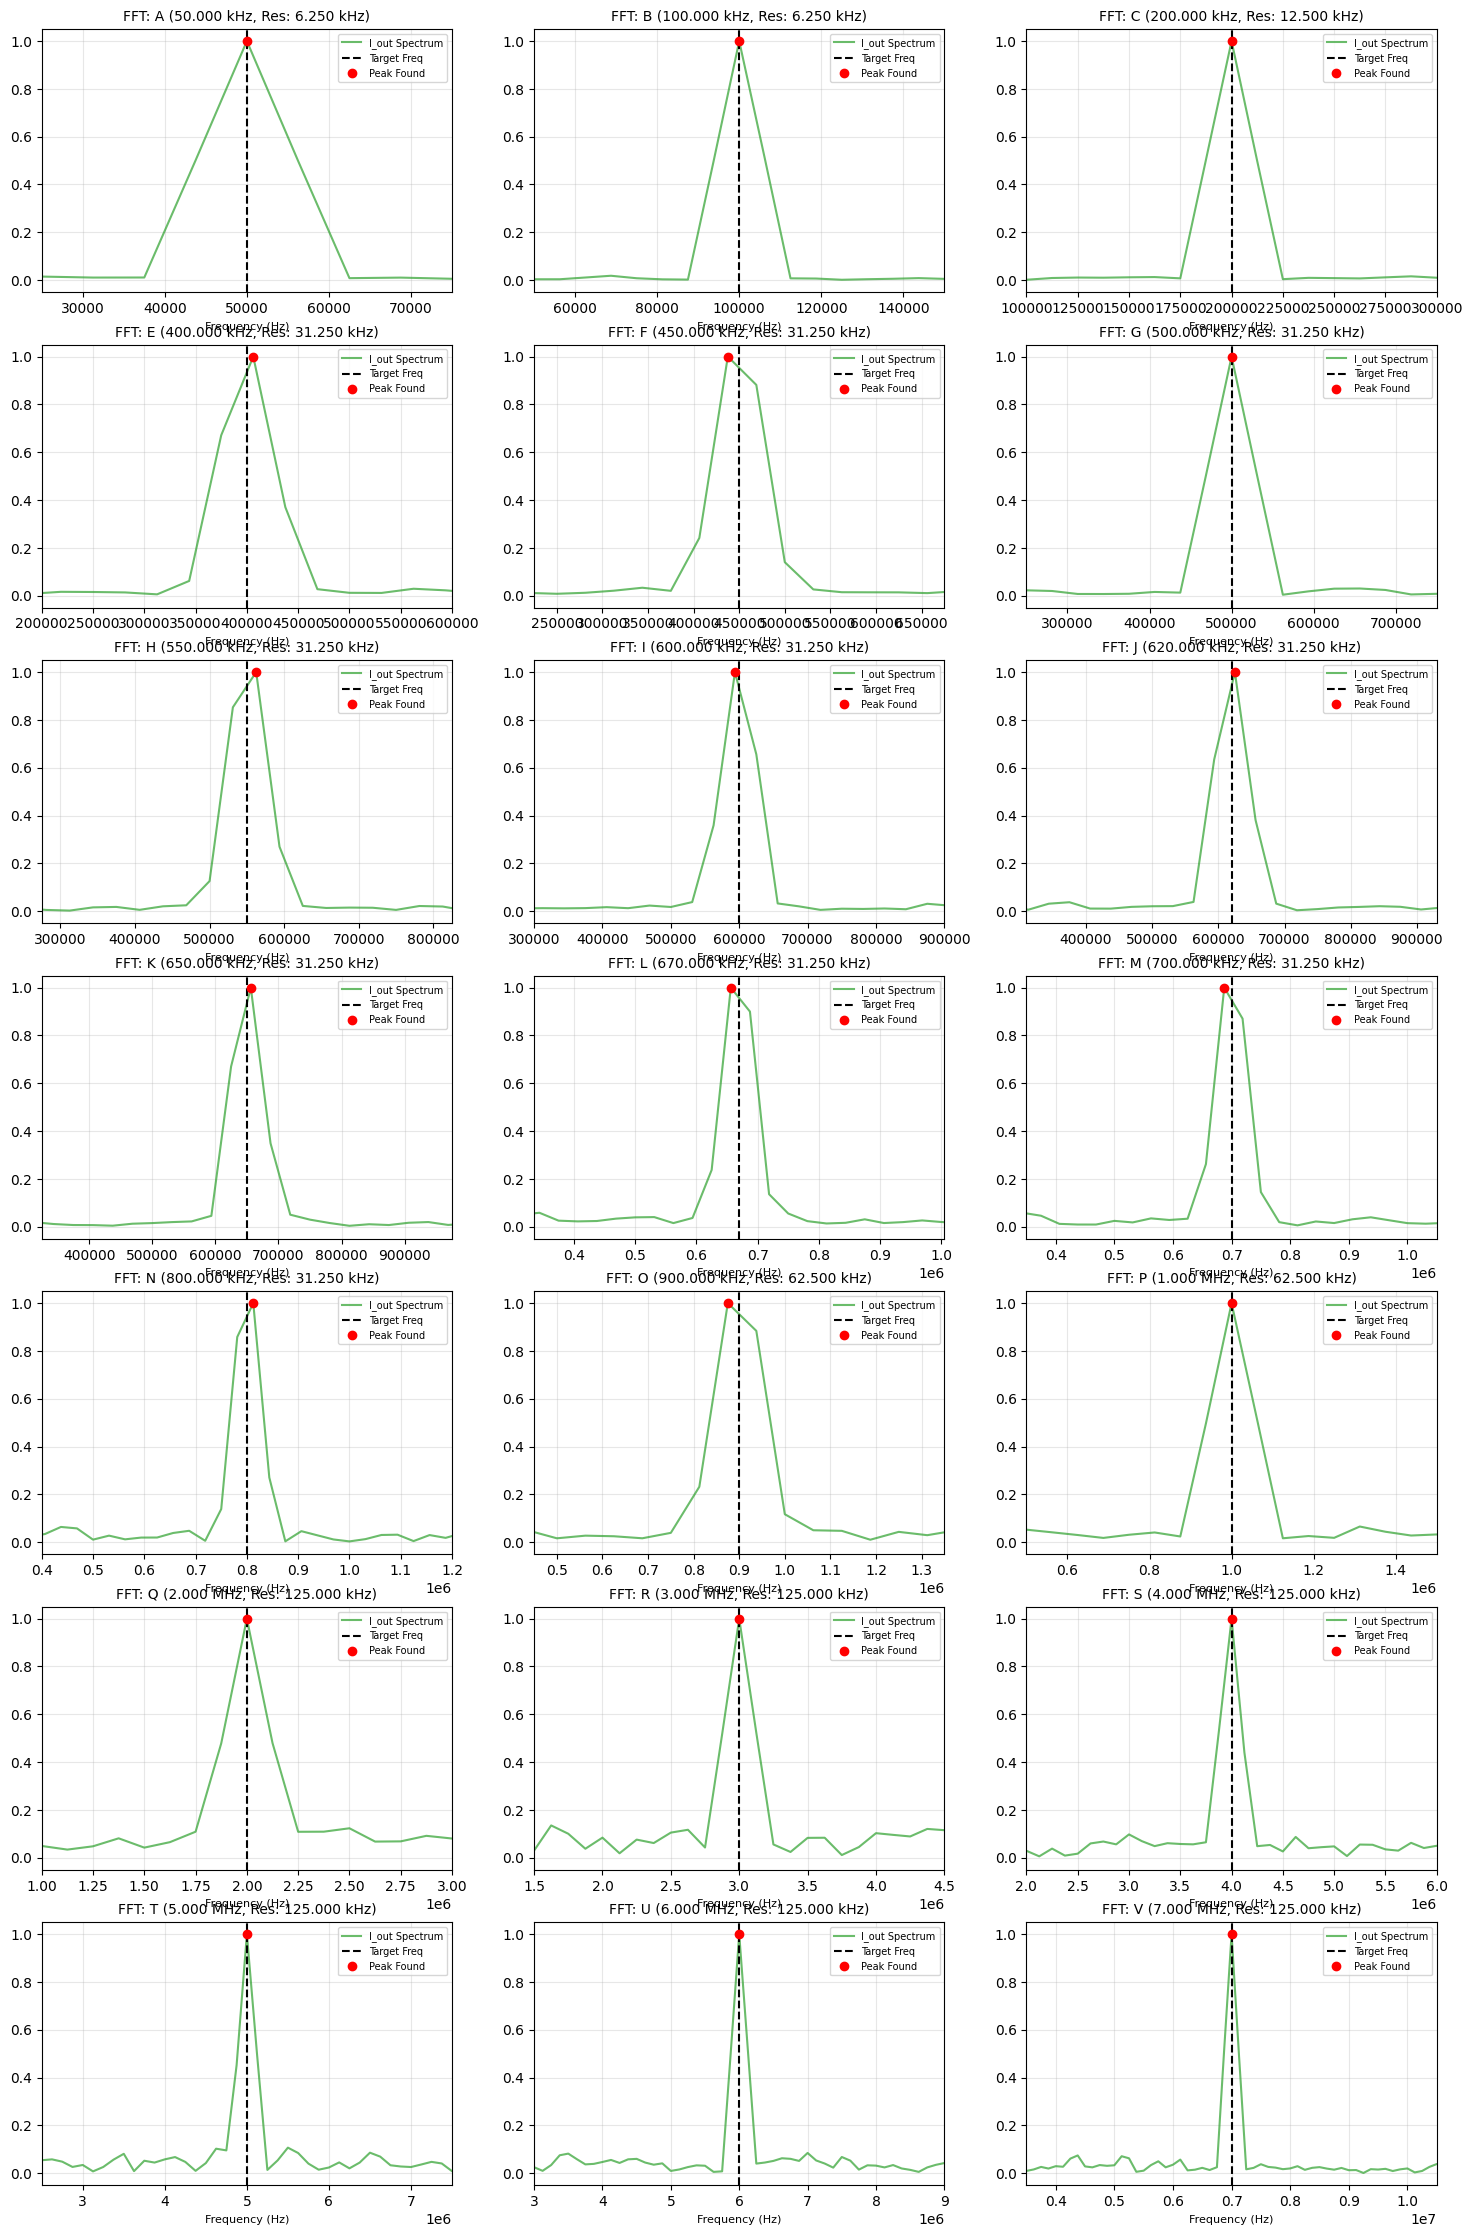

Saved: fitxers/BW_TX_v1/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v1
  Peak Freq:               100.000 kHz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 399.075 kHz
  Low-pass Bandwidth:       399.075 kHz



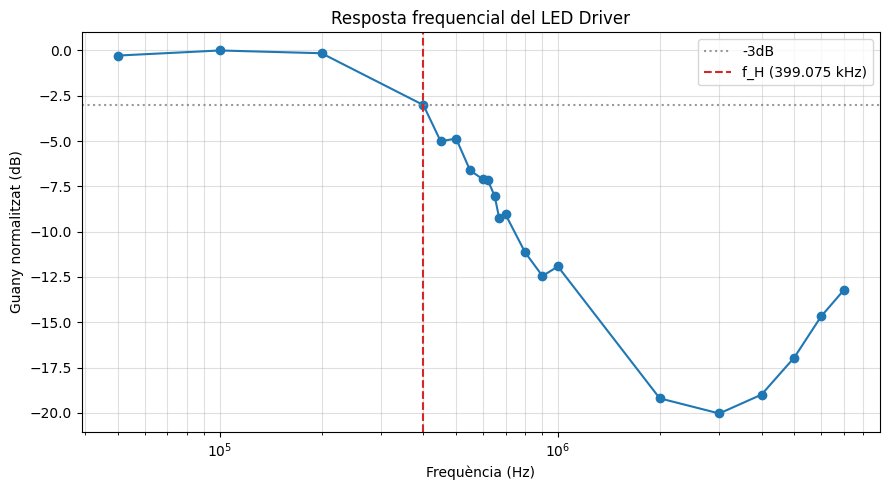

Saved: fitxers/BW_TX_v1/system_frequency_response.png


In [5]:
tx_rx_system.experiment1_BODE(
    freqs=[
        50000, 100000, 200000, 400000, 450000, 500000, 550000,
        600000, 620000, 650000, 670000, 700000, 800000, 900000, 1000000,
        2000000, 3000000, 4000000, 5000000, 6000000, 7000000,
    ],
    sampling_rates=[
        25e6, 25e6, 50e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 250e6, 250e6,
        500e6, 500e6, 500e6, 500e6, 500e6, 500e6,
    ],
    senyals=["a","b","c","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v"],
    folder="BW_TX_v1",
    resistencia=4.7,
)

Ara repetim l'experiment però emprant sondes en comptes de cables normals amb cocodrils. I importem els .csv amb 400k punts en comptes de 4k punts (més resolució).

Processing A (Target: 1.000 Hz)...
Guardat: fitxers/BW_TX_v2/a_neta_rx.csv i fitxers/BW_TX_v2/a_neta_tx.csv
  Amplitude: 128.8779 mA  |  Found at: 1.000 Hz
Processing B (Target: 2.000 Hz)...
Guardat: fitxers/BW_TX_v2/b_neta_rx.csv i fitxers/BW_TX_v2/b_neta_tx.csv
  Amplitude: 128.8802 mA  |  Found at: 2.000 Hz
Processing C (Target: 5.000 Hz)...
Guardat: fitxers/BW_TX_v2/c_neta_rx.csv i fitxers/BW_TX_v2/c_neta_tx.csv
  Amplitude: 127.7587 mA  |  Found at: 5.000 Hz
Processing D (Target: 10.000 Hz)...
Guardat: fitxers/BW_TX_v2/d_neta_rx.csv i fitxers/BW_TX_v2/d_neta_tx.csv
  Amplitude: 125.2794 mA  |  Found at: 10.000 Hz
Processing E (Target: 20.000 Hz)...
Guardat: fitxers/BW_TX_v2/e_neta_rx.csv i fitxers/BW_TX_v2/e_neta_tx.csv
  Amplitude: 123.3945 mA  |  Found at: 20.000 Hz
Processing F (Target: 50.000 Hz)...
Guardat: fitxers/BW_TX_v2/f_neta_rx.csv i fitxers/BW_TX_v2/f_neta_tx.csv
  Amplitude: 113.4356 mA  |  Found at: 50.000 Hz
Processing G (Target: 100.000 Hz)...
Guardat: fitxers/BW_T

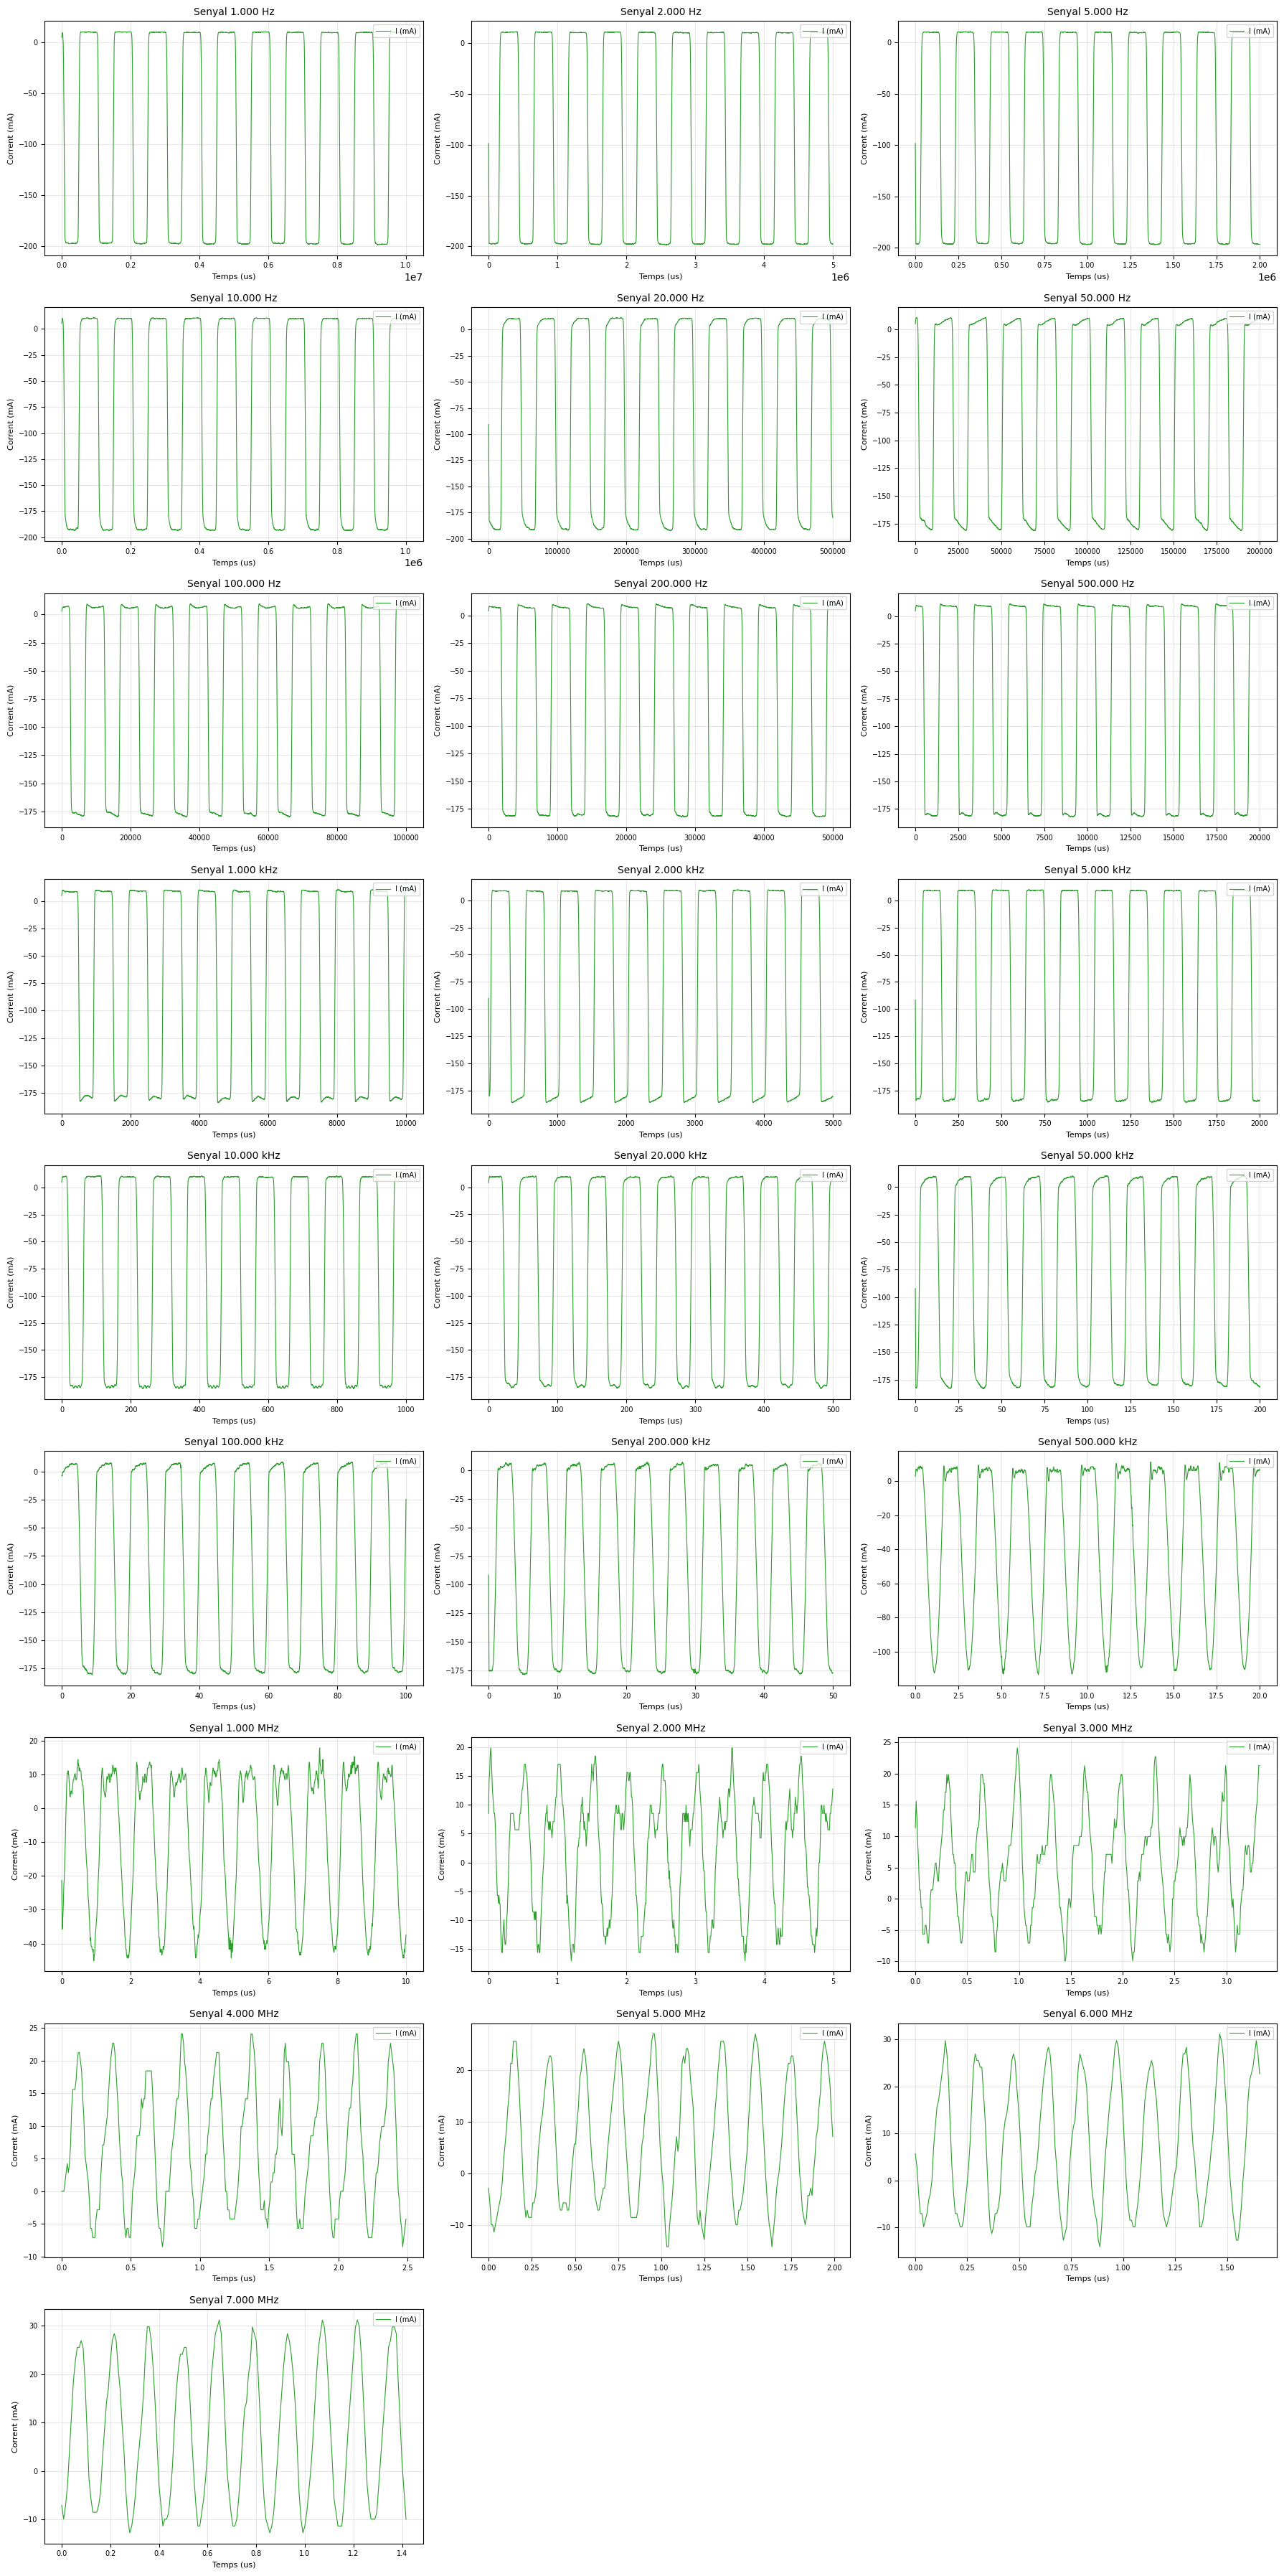

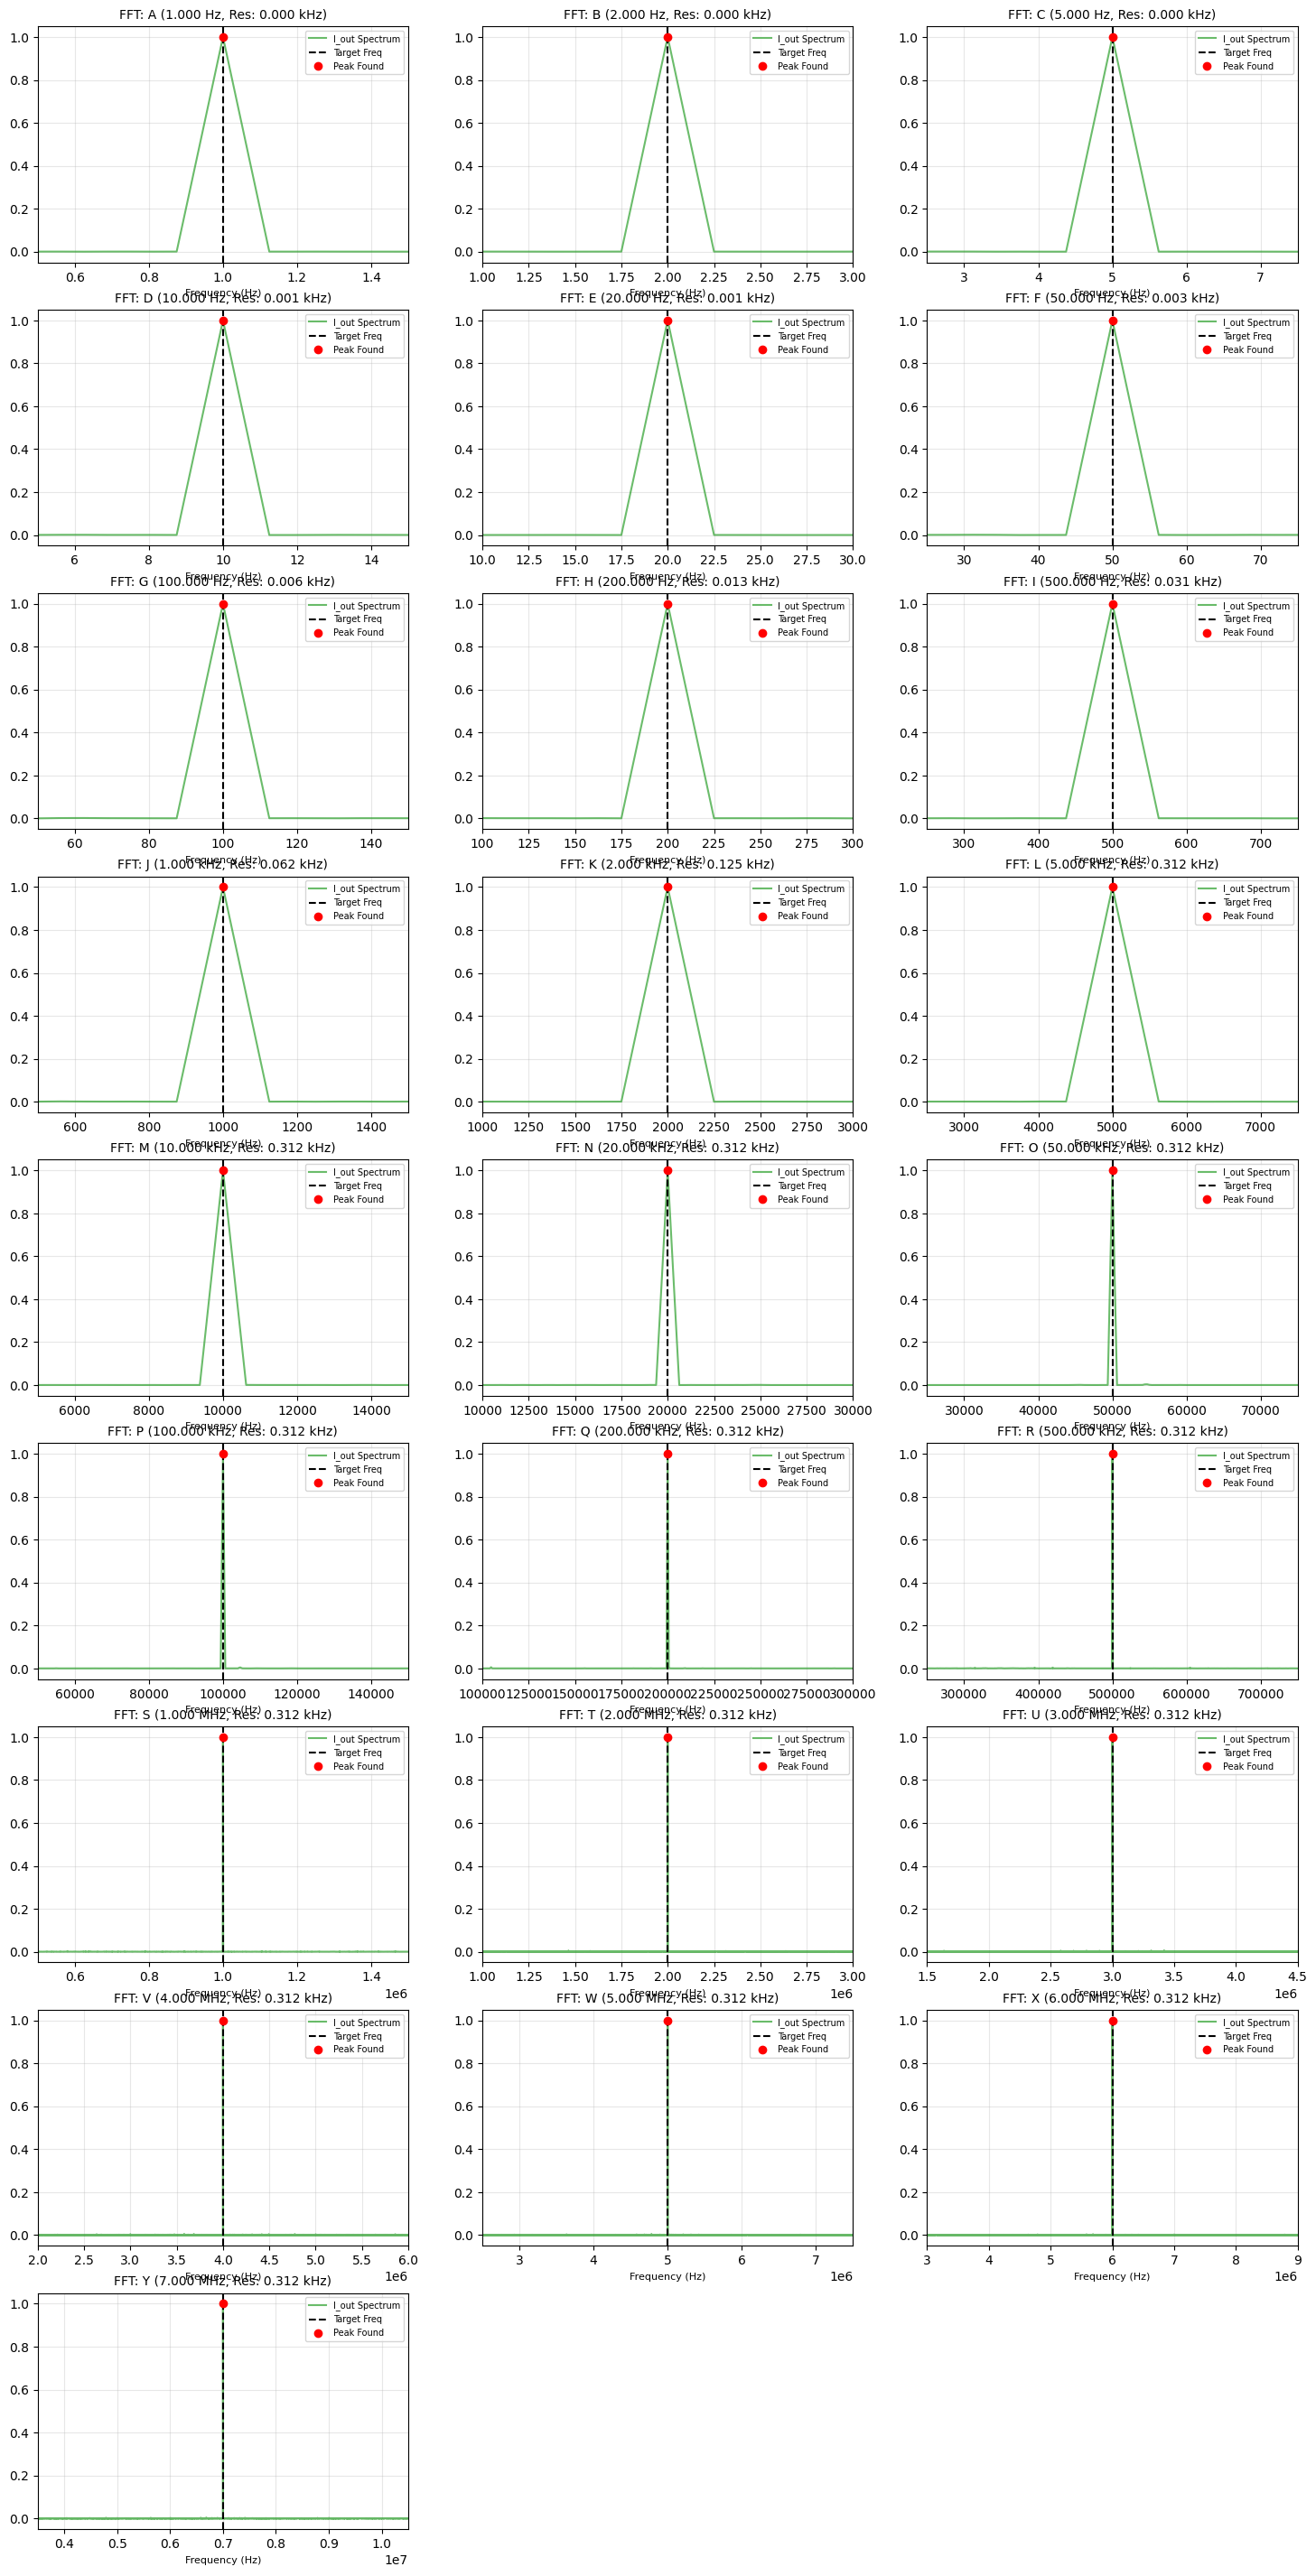

Saved: fitxers/BW_TX_v2/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v2
  Peak Freq:               2.000 Hz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 261.110 kHz
  Low-pass Bandwidth:       261.110 kHz



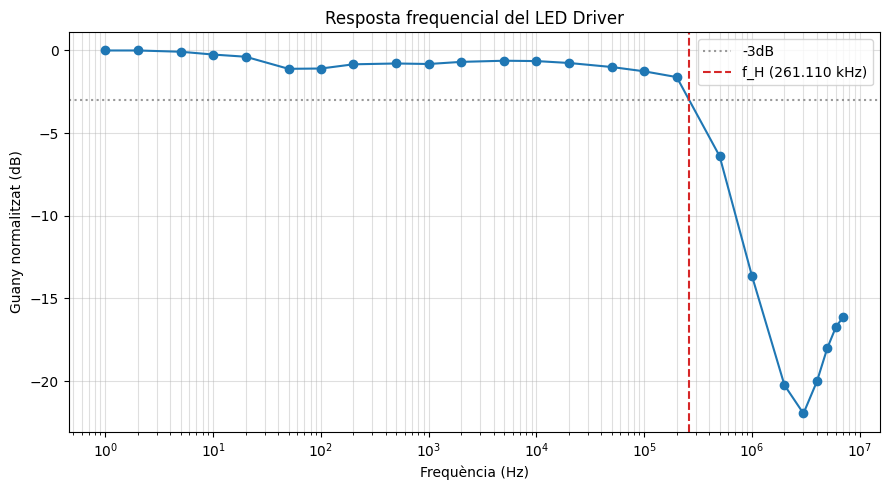

Saved: fitxers/BW_TX_v2/system_frequency_response.png


In [6]:
tx_rx_system.experiment1_BODE(
    freqs=[
        1, 2, 5, 10, 20, 50, 100, 200, 500,
        1e3, 2e3, 5e3, 10e3, 20e3, 50e3, 100e3, 200e3, 500e3,
        1e6, 2e6, 3e6, 4e6, 5e6, 6e6, 7e6,
    ],
    sampling_rates=[
        25e3, 50e3, 125e3, 250e3, 500e3, 1.25e6, 2.5e6, 5e6, 12.5e6,
        25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y"],
    folder="BW_TX_v2",
    resistencia=4.7,
)

Anem també a mesurar a 300k i 400k per tenir més precisió a l'hora de calcular bw:

KeyboardInterrupt: 

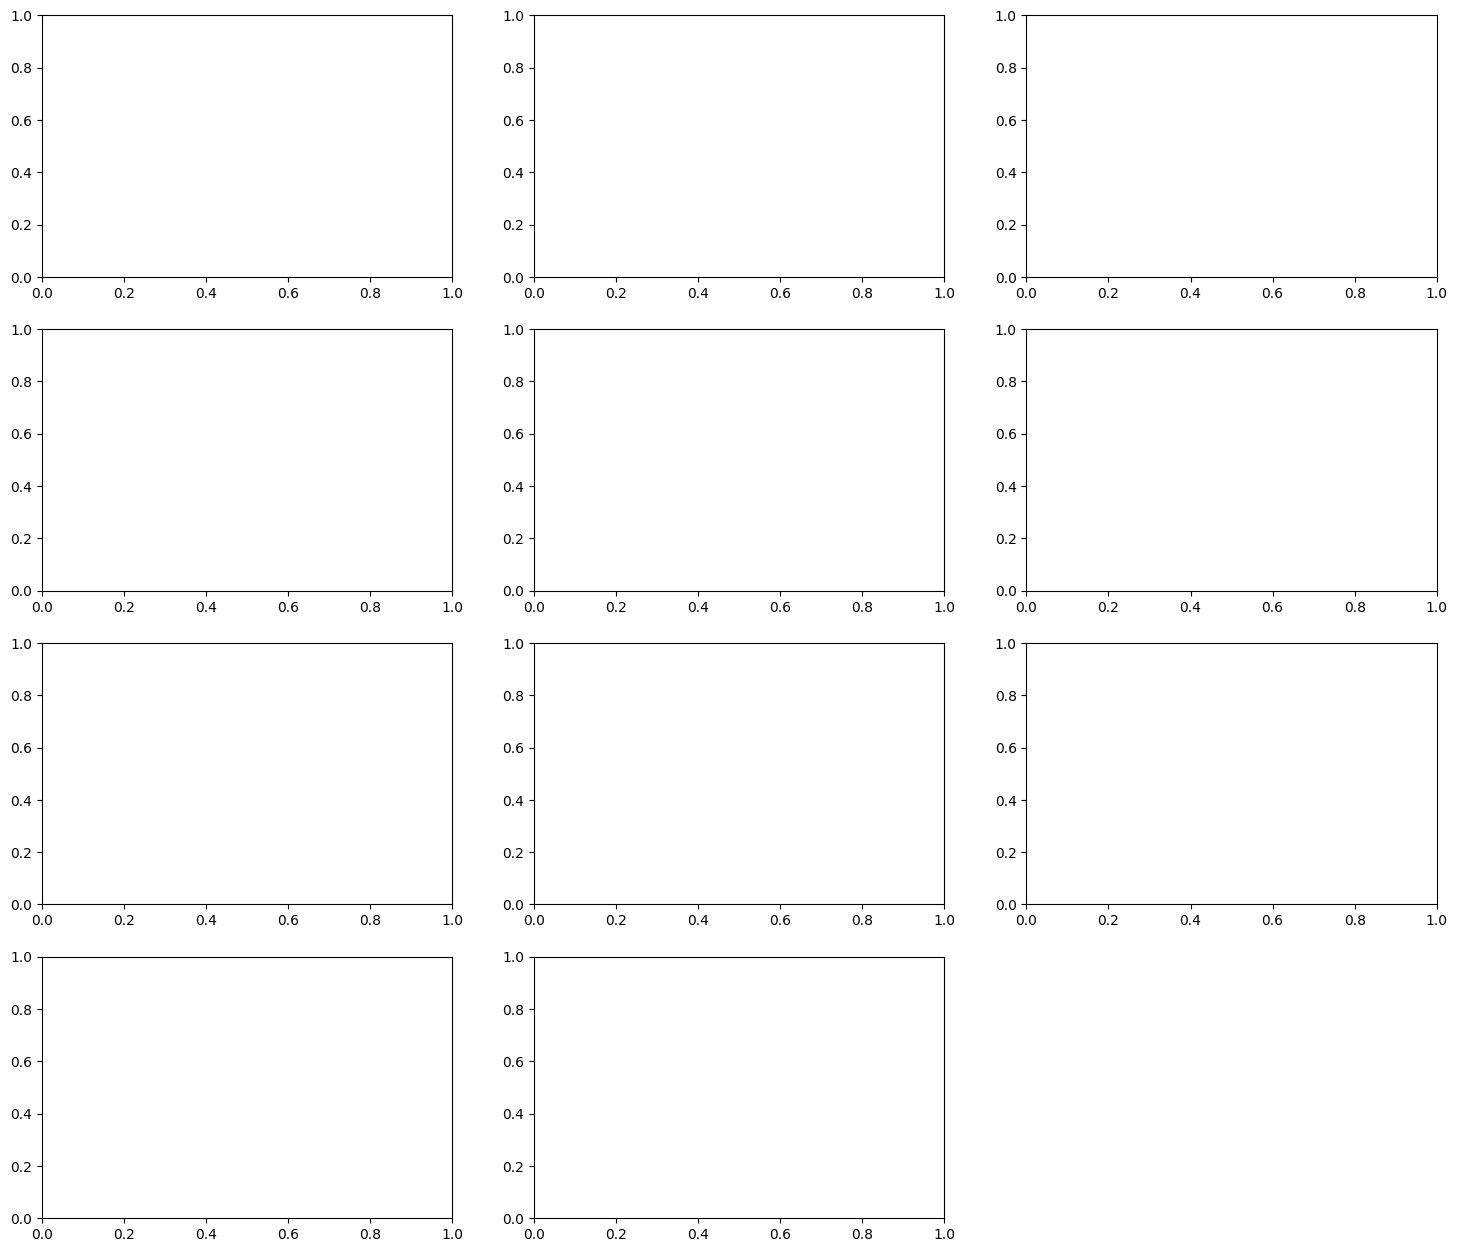

In [7]:
tx_rx_system.experiment1_BODE(
    freqs=[
        1, 2, 5, 10, 20, 50, 100, 200, 500,
        1e3, 2e3, 5e3, 10e3, 20e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3,
        1e6, 2e6, 3e6, 4e6, 5e6, 6e6, 7e6,
    ],
    sampling_rates=[
        25e3, 50e3, 125e3, 250e3, 500e3, 1.25e6, 2.5e6, 5e6, 12.5e6,
        25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","z","0","r","s","t","u","v","w","x","y"],
    folder="BW_TX_v2",
    resistencia=4.7,
)

## EXPERIMENT 2: Ample de banda del receptor amb senyal del LED driver

Per tal de fer aquest experiment, s'ha emprat una senyal quadrada de 3.3 V amb una 
freqüència d'1 kHz. S'ha mesurat el temps de pujada (*rise time*) de la sortida del 
OPT101 amb l'oscil·loscopi, obtenint:

$$V_{max} = 2.64 \ \text{V}, \qquad V_{min} = 0 \ \text{V}$$

Els llindars del 10\% i 90\% són:

$$V_{10\%} = 0.1 \times 2.64 = 0.264 \ \text{V}$$
$$V_{90\%} = 0.9 \times 2.64 = 2.376 \ \text{V}$$

El temps de pujada mesurat entre aquests dos llindars és:

$$t_r \approx 20 \ \mu\text{s}$$

L'ample de banda del receptor s'obté a partir de la relació entre el temps de pujada 
d'un sistema de primer ordre RC i la seva freqüència de tall:

$$B = \frac{0.35}{t_r}$$

Substituint el valor mesurat:

$$B = \frac{0.35}{20 \times 10^{-6}} \approx 17.5 \ \text{kHz}$$

Aquest resultat és consistent amb el valor teòric de 14.5 kHz obtingut a partir dels 
paràmetres interns del OPT101 ($R_f = 1\ \text{M}\Omega$, $C_f = 11\ \text{pF}$):

$$B_{teoria} = \frac{1}{2\pi R_f C_f} = \frac{1}{2\pi \times 1\ \text{M}\Omega \times 11\ \text{pF}} = 14.5 \ \text{kHz}$$



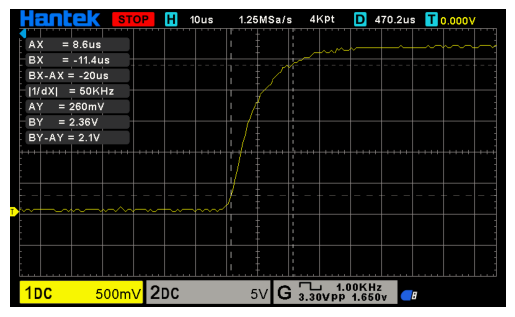

In [ ]:
img = plt.imread("./fitxers/BW_receptor.bmp")
plt.imshow(img)
plt.axis("off")
plt.show()

## EXPERIMENT 3: BER vs Bitrate (Capacitat del canal)

#### Escombrar el bitrate des de valors baixos fins al límit analògic prèviament trobat. & Corba de BER vs $R_b$ i extracció del valor pràctic de $R_b^{\max}$.

In [ ]:
#tx_rx_system.generate_prbs() 


Saved OOK signal to fitxers/prbs.csv
Executing: python3 utils/csv2arb.py fitxers/prbs.csv
Conversion complete. ARB file saved as 'fitxers/prbs.arb'.


array([1, 0, 1, ..., 1, 1, 1], shape=(4096,), dtype=uint8)

Un cop generada la senyal, anem a realitzar l'escombrat

  a                               BER = 0.000000  (0/4094 errors)  @77 baud
  b                               BER = 0.000000  (0/4094 errors)  @309 baud
  c                               BER = 0.000000  (0/4094 errors)  @966 baud
  d                               BER = 0.000000  (0/4094 errors)  @1933 baud
  e                               BER = 0.000000  (0/4094 errors)  @3092 baud
  f                               BER = 0.000000  (0/4094 errors)  @9664 baud
  g                               BER = 0.000000  (0/4094 errors)  @19327 baud
  ff                              BER = 0.000000  (0/4094 errors)  @20972 baud
  gg                              BER = 0.214216  (877/4094 errors)  @26307 baud
  ggg                             BER = 0.223986  (917/4094 errors)  @34360 baud
  gggg                            BER = 0.201270  (824/4094 errors)  @43487 baud
  ggggg                           BER = 0.234978  (962/4094 errors)  @53687 baud
  gggggg                          BER = 0.233024  (954

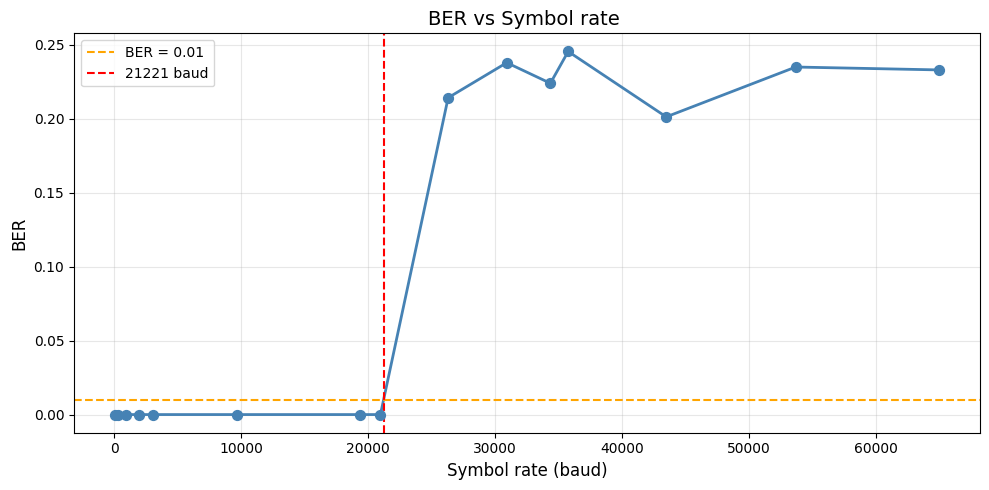

  a                               BER = 0.000978  (1/1023 errors)  @39 baud
  b                               BER = 0.000978  (1/1023 errors)  @155 baud
  c                               BER = 0.000978  (1/1023 errors)  @483 baud
  d                               BER = 0.000978  (1/1023 errors)  @966 baud
  e                               BER = 0.000978  (1/1023 errors)  @1546 baud
  f                               BER = 0.000978  (1/1023 errors)  @4832 baud
  g                               BER = 0.000978  (1/1023 errors)  @9664 baud
  ff                              BER = 0.000978  (1/1023 errors)  @10486 baud
  gg                              BER = 0.168133  (172/1023 errors)  @13153 baud
  ggg                             BER = 0.193548  (198/1023 errors)  @17180 baud
  gggg                            BER = 0.178886  (183/1023 errors)  @21743 baud
  ggggg                           BER = 0.335288  (343/1023 errors)  @26844 baud
  gggggg                          BER = 0.314761  (322/1

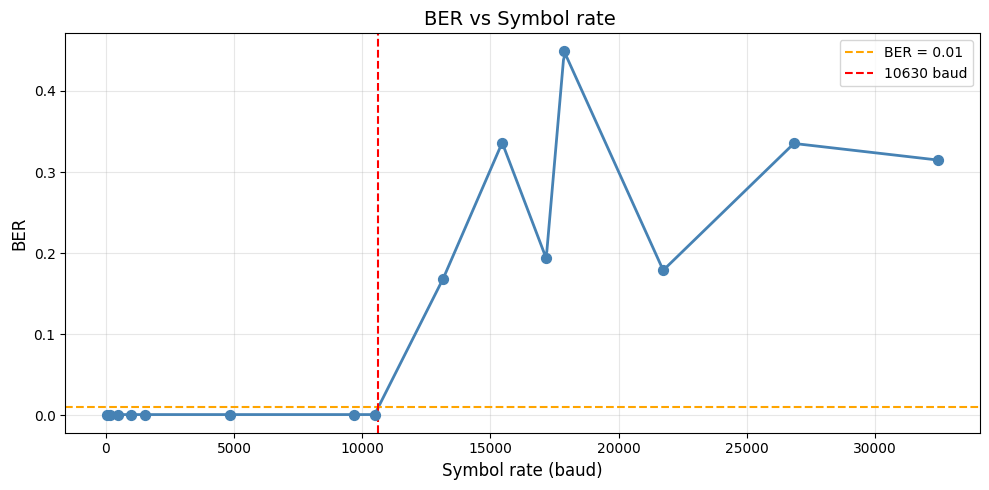

  a                               BER = 0.000000  (0/4094 errors)  @77 baud
  l                               BER = 0.046165  (189/4094 errors)  @84 baud
  o                               BER = 0.237909  (974/4094 errors)  @87 baud
  m                               BER = 0.235711  (965/4094 errors)  @91 baud
  n                               BER = 0.236199  (967/4094 errors)  @98 baud
  h                               BER = 0.231314  (947/4094 errors)  @105 baud
  i                               BER = 0.240840  (986/4094 errors)  @137 baud
  j                               BER = 0.241085  (987/4094 errors)  @174 baud
  k                               BER = 0.244016  (999/4094 errors)  @215 baud
  b                               BER = 0.244016  (999/4094 errors)  @309 baud
  e                               BER = 0.241573  (989/4094 errors)  @310 baud
  f                               BER = 0.188324  (771/4094 errors)  @520 baud
  g                               BER = 0.240596  (985/4094

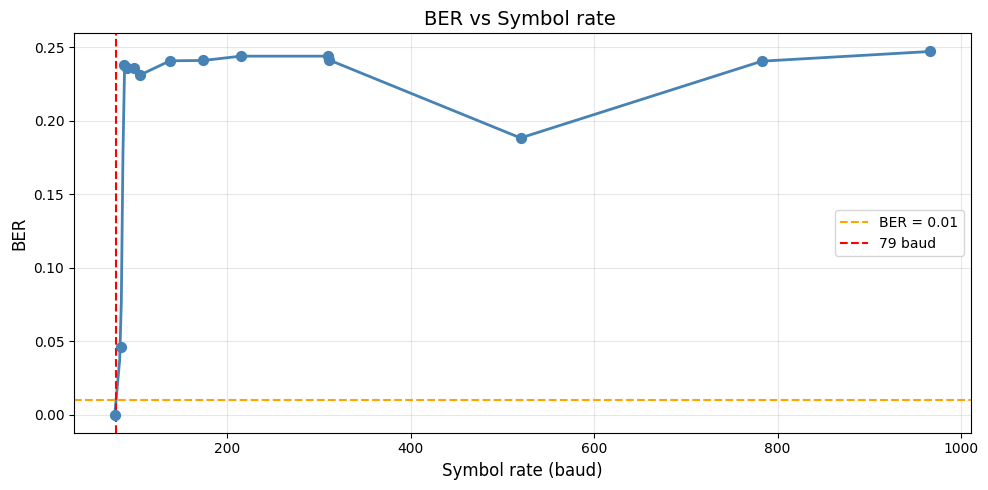

  a                               BER = 0.000978  (1/1023 errors)  @39 baud
  l                               BER = 0.020528  (21/1023 errors)  @42 baud
  o                               BER = 0.347019  (355/1023 errors)  @44 baud
  m                               BER = 0.212121  (217/1023 errors)  @45 baud
  n                               BER = 0.333333  (341/1023 errors)  @49 baud
  h                               BER = 0.238514  (244/1023 errors)  @53 baud
  i                               BER = 0.381232  (390/1023 errors)  @69 baud
  j                               BER = 0.406647  (416/1023 errors)  @87 baud
  k                               BER = 0.407625  (417/1023 errors)  @107 baud
  b                               BER = 0.407625  (417/1023 errors)  @155 baud
  e                               BER = 0.393939  (403/1023 errors)  @155 baud
  f                               BER = 0.383187  (392/1023 errors)  @260 baud
  g                               BER = 0.421310  (431/1023 err

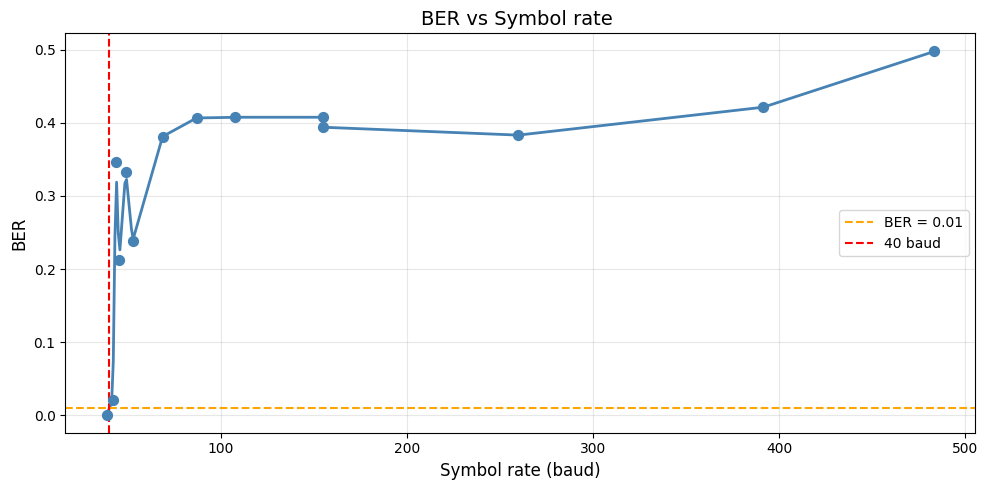

{'a': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'bit_rate': np.float64(38.654705664)},
 'l': {'ber': 0.020527859237536656,
  'errors': 21,
  'total': 1023,
  'bit_rate': np.float64(41.94304)},
 'o': {'ber': 0.34701857282502446,
  'errors': 355,
  'total': 1023,
  'bit_rate': np.float64(43.637538816)},
 'm': {'ber': 0.21212121212121213,
  'errors': 217,
  'total': 1023,
  'bit_rate': np.float64(45.365592064000005)},
 'n': {'ber': 0.3333333333333333,
  'errors': 341,
  'total': 1023,
  'bit_rate': np.float64(48.922361856000016)},
 'h': {'ber': 0.23851417399804498,
  'errors': 244,
  'total': 1023,
  'bit_rate': np.float64(52.61334937600001)},
 'i': {'ber': 0.3812316715542522,
  'errors': 390,
  'total': 1023,
  'bit_rate': np.float64(68.719476736)},
 'j': {'ber': 0.4066471163245357,
  'errors': 416,
  'total': 1023,
  'bit_rate': np.float64(86.97308774400001)},
 'k': {'ber': 0.40762463343108507,
  'errors': 417,
  'total': 1023,
  'bit_rate': np.float64(107.3741824

In [4]:

N_BITS = 4096
freqs =np.array([0.24, 0.48, 1.2, 2.4, 4.8, 12, 24, 25, 28, 32, 36, 40, 44, 48, 73])
T_s = 1/freqs
time_bit= T_s / N_BITS
sampling_rates=np.array([12.5e3, 12.5e3, 25e3, 50e3, 125e3, 250e3, 500e3, 500e3,500e3,500e3,500e3,500e3,500e3,1.25e6, 2.5e6])
time_per_sample =1/sampling_rates
samples_per_bit = time_bit / time_per_sample
signals= ["a","b","c","d","e","f", "g", "ff", "gg","ggg","gggg","ggggg","gggggg","h","i"]
bit_rates = freqs * N_BITS/samples_per_bit


# FOSCOR
## OOK
#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_OOK/prbs.csv", mode="OOK")
tx_rx_system.experiment2_BERvsBitrate(signals, samples_per_bit, bit_rates, experiment="BER_OOK_DARK", ref="prbs.csv", mode="OOK", channels = 1, version=2)

## MANCHESTER
#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_MNCH/prbs.csv", mode="MANCHESTER", size=2048)
tx_rx_system.experiment2_BERvsBitrate(signals, samples_per_bit, bit_rates/2, experiment="BER_MNCH_DARK", ref="prbs_raw.csv", mode="MANCHESTER", channels = 1, version=2)


# LLUM
freqs =np.array([0.24,0.25,0.255, 0.26, 0.27, 0.28, 0.32, 0.36, 0.4, 0.48, 0.68, 0.88, 1.08, 1.2])
T_s = 1/freqs
time_bit= T_s / N_BITS
sampling_rates=np.array([12.5e3, 12.5e3,12.5e3, 12.5e3, 12.5e3,12.5e3,12.5e3,12.5e3,12.5e3,12.5e3, 25e3,25e3,25e3,25e3])
time_per_sample =1/sampling_rates
samples_per_bit = time_bit / time_per_sample
signals= ["a", "l", "o", "m", "n", "h", "i", "j", "k", "b","e","f","g", "c"]
bit_rates = freqs * N_BITS / samples_per_bit

## OOK
#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_OOK/prbs.csv", mode="OOK")
tx_rx_system.experiment2_BERvsBitrate(signals, samples_per_bit, bit_rates, experiment="BER_OOK_LIGHT", ref="prbs.csv", mode="OOK", channels = 1, version=2)

## MANCHESTER
#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_MNCH/prbs.csv", mode="MANCHESTER", size=2048)
tx_rx_system.experiment2_BERvsBitrate(signals, samples_per_bit, bit_rates/2, experiment="BER_MNCH_LIGHT", ref="prbs_raw.csv", mode="MANCHESTER", channels = 1, version=2)

## EXPERIMENT 4: DISTANCE vs BER 




  a                               BER = 0.242306  (992/4094 errors)  @5 cm
  b                               BER = 0.000000  (0/4094 errors)  @10 cm
  c                               BER = 0.000000  (0/4094 errors)  @20 cm
  d                               BER = 0.000000  (0/4094 errors)  @30 cm
  e                               BER = 0.000000  (0/4094 errors)  @40 cm
  f                               BER = 0.000000  (0/4094 errors)  @50 cm
  g                               BER = 0.000000  (0/4094 errors)  @55 cm
  h                               BER = 0.000000  (0/4094 errors)  @60 cm
  i                               BER = 0.000000  (0/4094 errors)  @65 cm
  j                               BER = 0.000000  (0/4094 errors)  @70 cm
  k                               BER = 0.000000  (0/4094 errors)  @75 cm
  l                               BER = 0.000000  (0/4094 errors)  @80 cm
  m                               BER = 0.006595  (27/4094 errors)  @85 cm
  n                               BE

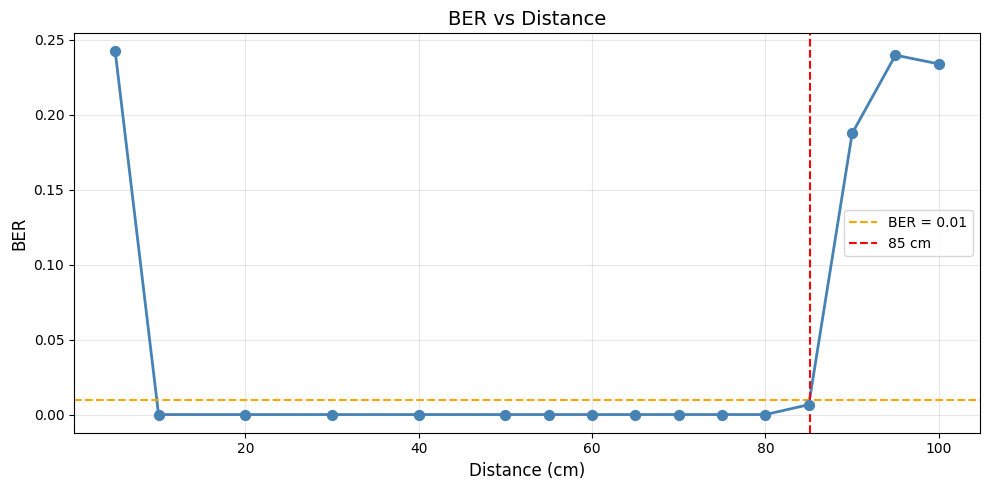

  a                               BER = 0.398827  (408/1023 errors)  @5 cm
  b                               BER = 0.000978  (1/1023 errors)  @10 cm
  c                               BER = 0.000978  (1/1023 errors)  @20 cm
  d                               BER = 0.000978  (1/1023 errors)  @30 cm
  e                               BER = 0.000978  (1/1023 errors)  @40 cm
  f                               BER = 0.000978  (1/1023 errors)  @50 cm
  g                               BER = 0.000978  (1/1023 errors)  @55 cm
  h                               BER = 0.000978  (1/1023 errors)  @60 cm
  i                               BER = 0.000978  (1/1023 errors)  @65 cm
  j                               BER = 0.000978  (1/1023 errors)  @70 cm
  k                               BER = 0.000978  (1/1023 errors)  @75 cm
  l                               BER = 0.000978  (1/1023 errors)  @80 cm
  m                               BER = 0.126100  (129/1023 errors)  @85 cm
  n                               B

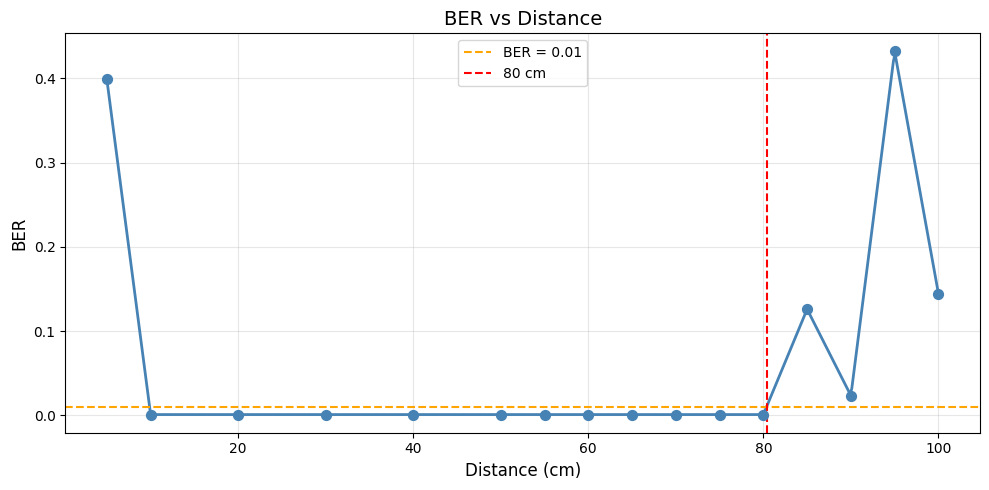

  aa                              BER = 0.241573  (989/4094 errors)  @5 cm
  bb                              BER = 0.220567  (903/4094 errors)  @10 cm
  cc                              BER = 0.000000  (0/4094 errors)  @20 cm
  dd                              BER = 0.000000  (0/4094 errors)  @30 cm
  ee                              BER = 0.000000  (0/4094 errors)  @40 cm
  ff                              BER = 0.000000  (0/4094 errors)  @50 cm
  gg                              BER = 0.000000  (0/4094 errors)  @55 cm
  hh                              BER = 0.000000  (0/4094 errors)  @60 cm
  ii                              BER = 0.105276  (431/4094 errors)  @65 cm
  jj                              BER = 0.235467  (964/4094 errors)  @70 cm
  kk                              BER = 0.291891  (1195/4094 errors)  @75 cm
  ll                              BER = 0.400830  (1641/4094 errors)  @80 cm
  mm                              BER = 0.268197  (1098/4094 errors)  @85 cm
  nn                  

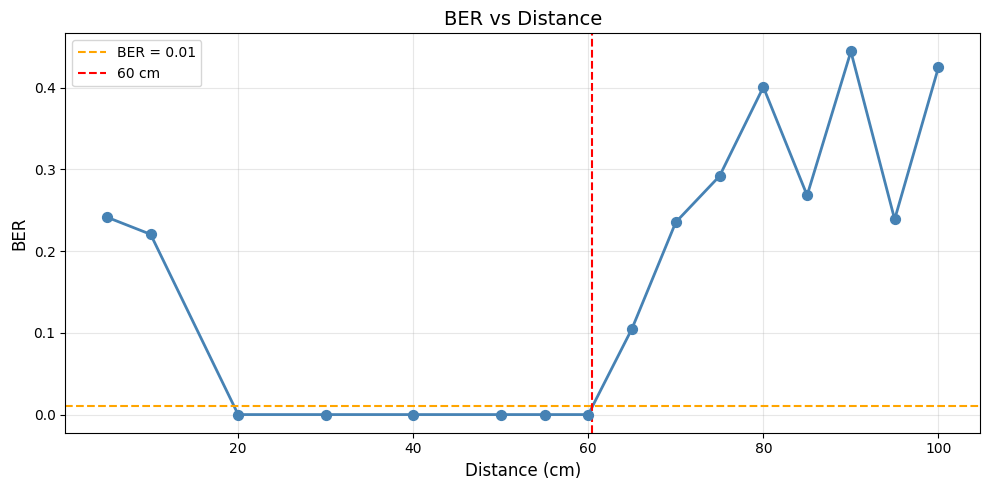

  aa                              BER = 0.405670  (415/1023 errors)  @5 cm
  bb                              BER = 0.168133  (172/1023 errors)  @10 cm
  cc                              BER = 0.000978  (1/1023 errors)  @20 cm
  dd                              BER = 0.000978  (1/1023 errors)  @30 cm
  ee                              BER = 0.000978  (1/1023 errors)  @40 cm
  ff                              BER = 0.000978  (1/1023 errors)  @50 cm
  gg                              BER = 0.000978  (1/1023 errors)  @55 cm
  hh                              BER = 0.037146  (38/1023 errors)  @60 cm
  ii                              BER = 0.185728  (190/1023 errors)  @65 cm
  jj                              BER = 0.462366  (473/1023 errors)  @70 cm


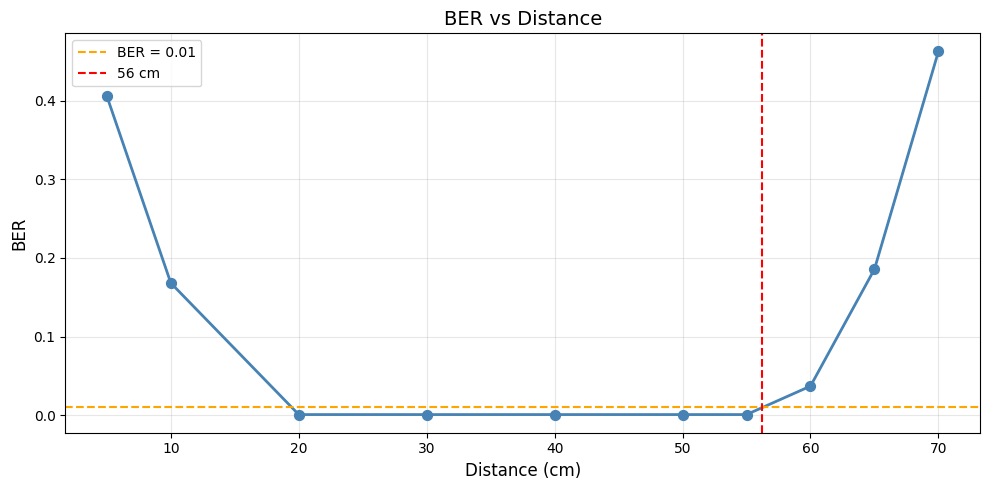

{'aa': {'ber': 0.4056695992179863,
  'errors': 415,
  'total': 1023,
  'distance': np.int64(5),
  'snr': np.float64(-13.71699305404556)},
 'bb': {'ber': 0.1681329423264907,
  'errors': 172,
  'total': 1023,
  'distance': np.int64(10),
  'snr': np.float64(-6.157638812951295)},
 'cc': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'distance': np.int64(20),
  'snr': np.float64(-10.904268490207281)},
 'dd': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'distance': np.int64(30),
  'snr': np.float64(-9.893082676945538)},
 'ee': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'distance': np.int64(40),
  'snr': np.float64(-8.515888780905863)},
 'ff': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'distance': np.int64(50),
  'snr': np.float64(-6.738048909705336)},
 'gg': {'ber': 0.0009775171065493646,
  'errors': 1,
  'total': 1023,
  'distance': np.int64(55),
  'snr': np.float64(-6.707363907676914)},
 'hh': {'ber': 0.03714

In [ ]:

N_BITS = 4096
freq = 1.2
T_s = 1/freq
time_bit= T_s / N_BITS


sampling_rates=50e3
time_per_sample = 1/sampling_rates
samples_per_bit = time_bit / time_per_sample
signals= ["a","b","c","d","e","f","g","h","i","j", "k","l","m","n","o","p"]  
distances = np.array([5,10,20,30,40,50,55,60,65,70,75,80,85,90,95,100]) 
# FOSCOR
tx_rx_system.experiment3_BERvsDISTANCE(signals, distances, samples_per_bit)

tx_rx_system.experiment3_BERvsDISTANCE(signals, distances, samples_per_bit,ref="prbs_raw.csv", mode="MANCHESTER")

# LLUM
signals= ["aa","bb","cc","dd","ee","ff","gg","hh","ii","jj", "kk","ll","mm","nn","oo","pp"] 
tx_rx_system.experiment3_BERvsDISTANCE(signals, distances, samples_per_bit) 

tx_rx_system.experiment3_BERvsDISTANCE(signals[:-6], distances[:-6], samples_per_bit,ref="prbs_raw.csv", mode="MANCHESTER") 


## EXPERIMENT 4: DISTANCE vs SNR


  a                               SNR =    0.49 dB, 1.1205744357341063 @   5.0 cm BER = 0.242306  (992/4094 errors)
  b                               SNR =   23.11 dB, 204.77775847089478 @  10.0 cm BER = 0.000000  (0/4094 errors)
  c                               SNR =   15.96 dB, 39.46218219494699 @  20.0 cm BER = 0.000000  (0/4094 errors)
  d                               SNR =   14.21 dB, 26.34184023804073 @  30.0 cm BER = 0.000000  (0/4094 errors)
  e                               SNR =    9.46 dB, 8.839662897375721 @  40.0 cm BER = 0.000000  (0/4094 errors)
  f                               SNR =    7.88 dB, 6.131743119266054 @  50.0 cm BER = 0.000000  (0/4094 errors)
  g                               SNR =    8.85 dB, 7.673134143317631 @  55.0 cm BER = 0.000000  (0/4094 errors)
  h                               SNR =    9.91 dB, 9.786583205385615 @  60.0 cm BER = 0.000000  (0/4094 errors)
  i                               SNR =    8.40 dB, 6.924291802456752 @  65.0 cm BER = 0.000

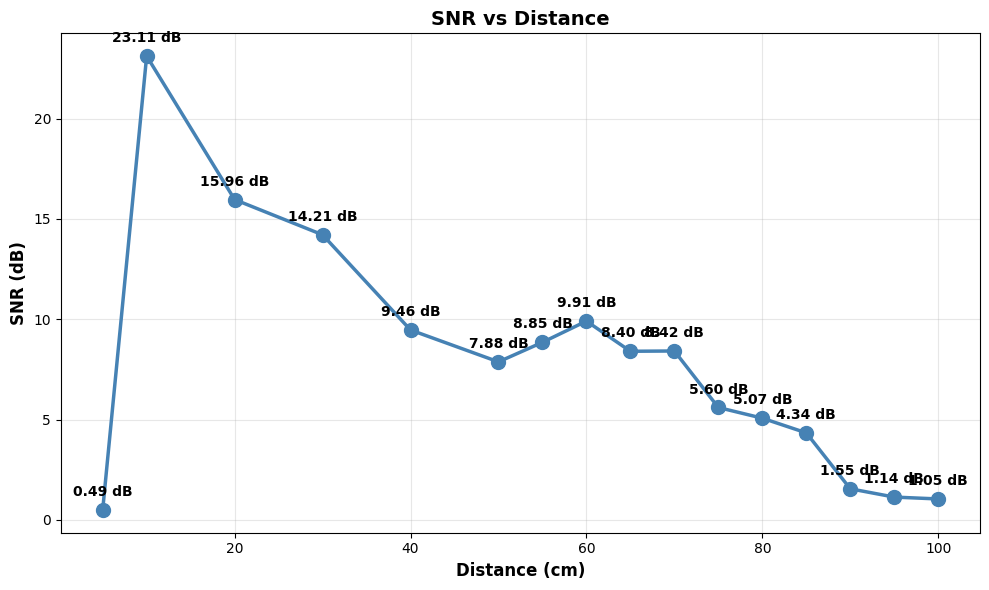


Saved plot to: fitxers/SNRvsDISTANCE/snr_vs_distance.png
  aa                              SNR =    0.43 dB, 1.1035216108754697 @   5.0 cm BER = 0.241573  (989/4094 errors)
  bb                              SNR =    0.85 dB, 1.214797386914166 @  10.0 cm BER = 0.220567  (903/4094 errors)
  cc                              SNR =   15.02 dB, 31.775409547296125 @  20.0 cm BER = 0.000000  (0/4094 errors)
  dd                              SNR =   11.15 dB, 13.039606580514267 @  30.0 cm BER = 0.000000  (0/4094 errors)
  ee                              SNR =    7.89 dB, 6.151625086969486 @  40.0 cm BER = 0.000000  (0/4094 errors)
  ff                              SNR =    7.22 dB, 5.273679145855296 @  50.0 cm BER = 0.000000  (0/4094 errors)
  gg                              SNR =   10.76 dB, 11.916255987869187 @  55.0 cm BER = 0.000000  (0/4094 errors)
  hh                              SNR =    5.74 dB, 3.7517381892270523 @  60.0 cm BER = 0.000000  (0/4094 errors)
  ii                         

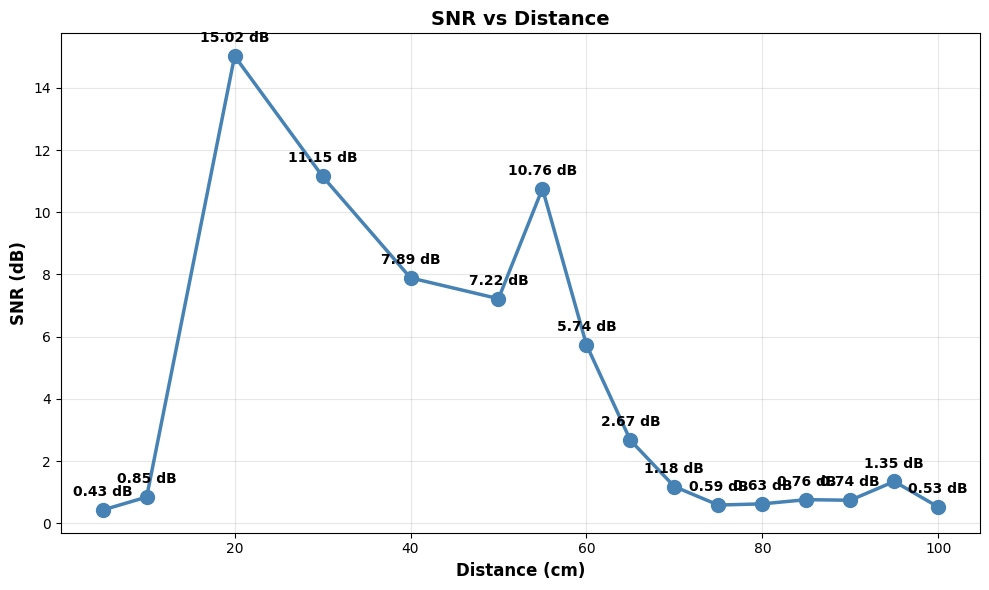


Saved plot to: fitxers/SNRvsDISTANCE/snr_vs_distance.png


{'aa': {'snr_db': np.float64(0.4278084261055508),
  'snr_linear': np.float64(1.1035216108754697),
  'distance': np.int64(5),
  'errors': 989,
  'total_signal': 4094},
 'bb': {'snr_db': np.float64(0.8450384905954746),
  'snr_linear': np.float64(1.214797386914166),
  'distance': np.int64(10),
  'errors': 903,
  'total_signal': 4094},
 'cc': {'snr_db': np.float64(15.020911568022708),
  'snr_linear': np.float64(31.775409547296125),
  'distance': np.int64(20),
  'errors': 0,
  'total_signal': 4094},
 'dd': {'snr_db': np.float64(11.152644884442742),
  'snr_linear': np.float64(13.039606580514267),
  'distance': np.int64(30),
  'errors': 0,
  'total_signal': 4094},
 'ee': {'snr_db': np.float64(7.889898593645891),
  'snr_linear': np.float64(6.151625086969486),
  'distance': np.int64(40),
  'errors': 0,
  'total_signal': 4094},
 'ff': {'snr_db': np.float64(7.2211370349621316),
  'snr_linear': np.float64(5.273679145855296),
  'distance': np.int64(50),
  'errors': 0,
  'total_signal': 4094},
 'gg'

In [ ]:

N_BITS = 4096
freq = 1.2
T_s = 1/freq
time_bit= T_s / N_BITS


sampling_rates=50e3
time_per_sample = 1/sampling_rates
samples_per_bit = time_bit / time_per_sample
signals= ["a","b","c","d","e","f","g","h","i","j", "k","l","m","n","o","p"]  
distances = np.array([5,10,20,30,40,50,55,60,65,70,75,80,85,90,95,100]) 
bit_rate = freq * N_BITS

# FOSCOR
tx_rx_system.experiment4_SNRvsDISTANCE(signals, distances, samples_per_bit)
# LLUM
signals= ["aa","bb","cc","dd","ee","ff","gg","hh","ii","jj", "kk","ll","mm","nn","oo","pp"] 
tx_rx_system.experiment4_SNRvsDISTANCE(signals, distances, samples_per_bit) 